In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style(
    rc={"patch.force_edgecolor": True, "patch.edgecolor": "black", "font": "Palatino"}
)
sns.set_style("ticks")

plt.rcParams["font.family"] = "Palatino"  # change to palatino
plt.rcParams["font.size"] = 10  # change to palatino

In [2]:
langs = ["de", "fr", "pt", "nl", "ko"]

In [3]:
dfs = []
for lang in langs:
    path = f"../tacl_results/wmt24_chat/test.en-{lang}.csv"
    df = pd.read_csv(path)
    dfs.append(df)
df = pd.concat(dfs)
df.columns

Index(['source_language', 'target_language', 'source', 'reference', 'doc_id',
       'client_id', 'sender', 'tags', 'lp', 'baseline', 'baseline-comet',
       'greedy-7b-w-context', 'greedy-7b-w-context-comet',
       'greedy-7b-wo-context', 'greedy-7b-wo-context-comet',
       'greedy-7b-5shot-w-context', 'greedy-7b-5shot-w-context-comet',
       'greedy-7b-5shot-wo-context', 'greedy-7b-5shot-wo-context-comet',
       'greedy-7b-ft-w-context', 'greedy-7b-ft-w-context-comet',
       'greedy-7b-ft-wo-context', 'greedy-7b-ft-wo-context-comet', 'mbr',
       'mbr-comet', 'mbr-source', 'mbr-source-comet', 'mbr-hyp',
       'mbr-hyp-comet', 'greedy-70b-5shot-w-context',
       'greedy-70b-5shot-w-context-comet', 'greedy-70b-5shot-wo-context',
       'greedy-70b-5shot-wo-context-comet', 'baseline-context-comet-qe',
       'greedy-7b-w-context-context-comet-qe',
       'greedy-7b-wo-context-context-comet-qe',
       'greedy-7b-5shot-w-context-context-comet-qe',
       'greedy-7b-5shot-wo-cont

In [4]:
model = "greedy-7b-ft"
pcxmi_model = "TowerInstruct-v0.2-w-chat-mt-data"
dataset = "wmt24_chat_test"
df["context_helps"] = df.apply(
    lambda x: (
        1
        if x[f"{model}-w-context-comet"] > x[f"{model}-wo-context-comet"]
        else 0 if x[f"{model}-w-context-comet"] < x[f"{model}-wo-context-comet"] else -1
    ),
    axis=1,
)
# break df in the comet bins: [0, 0.3], [0.3, 0.4], [0.4, 0.5], [0.5, 0.6], [0.6, 0.7], [0.7, 0.8], [0.8, 0.9], [0.9, 1]
df["comet_bin"] = pd.cut(
    df[f"{model}-wo-context-comet"],
    bins=[0, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    labels=[
        "[0, 0.5]",
        "[0.5, 0.6]",
        "[0.6, 0.7]",
        "[0.7, 0.8]",
        "[0.8, 0.9]",
        "[0.9, 1]",
    ],
)
print(df["comet_bin"].value_counts())
df.groupby(by="lp")["context_helps"].value_counts(normalize=True)

comet_bin
[0.9, 1]      7832
[0.8, 0.9]    1812
[0.7, 0.8]     373
[0.6, 0.7]     108
[0.5, 0.6]      34
[0, 0.5]        10
Name: count, dtype: int64


lp        context_helps
de-en     -1               0.470120
           0               0.273904
           1               0.255976
en-de     -1               0.403086
           1               0.345227
           0               0.251688
en-fr     -1               0.462911
           1               0.331455
           0               0.205634
en-ko      1               0.384162
          -1               0.358888
           0               0.256950
en-nl      1               0.586239
          -1               0.245994
           0               0.167766
en-pt-br  -1               0.517613
           1               0.307241
           0               0.175147
fr-en     -1               0.501949
           0               0.251462
           1               0.246589
ko-en     -1               0.700629
           1               0.173585
           0               0.125786
nl-en     -1               0.575472
           1               0.241090
           0               0.183438
pt-b

# PCXMI bins

In [5]:
from tower_eval.utils import read_lines

df["pcxmi_fc_nc_on_fc"] = 0.0  # classic pcxmi
df["pcxmi_fc_nc_on_nc"] = 0.0  # for pcxmi diff
df["lhood_diff"] = 0.0  # what we had in the paper

for lp in [
    "en-de",
    "en-fr",
    "en-nl",
    "en-pt-br",
    "en-ko",
    "de-en",
    "fr-en",
    "nl-en",
    "pt-br-en",
    "ko-en",
]:
    log_probs_fc_on_fc = [
        float(l)
        for l in read_lines(
            f"../pcxmi_hyps/full_context_input_on_full_context_output/mt/{dataset}.{lp}/{pcxmi_model}/mean_log_probs.txt"
        )
    ]
    log_probs_fc_on_nc = [
        float(l)
        for l in read_lines(
            f"../pcxmi_hyps/full_context_input_on_no_context_output/mt/{dataset}.{lp}/{pcxmi_model}/mean_log_probs.txt"
        )
    ]
    log_probs_nc_on_nc = [
        float(l)
        for l in read_lines(
            f"../pcxmi_hyps/no_context_input_on_no_context_output/mt/{dataset}.{lp}/{pcxmi_model}/mean_log_probs.txt"
        )
    ]
    log_probs_nc_on_fc = [
        float(l)
        for l in read_lines(
            f"../pcxmi_hyps/no_context_input_on_full_context_output/mt/{dataset}.{lp}/{pcxmi_model}/mean_log_probs.txt"
        )
    ]

    df.loc[(df["lp"] == lp), "pcxmi_fc_nc_on_fc"] = [
        w - wo for w, wo in zip(log_probs_fc_on_fc, log_probs_nc_on_fc)
    ]
    df.loc[(df["lp"] == lp), "pcxmi_fc_nc_on_nc"] = [
        w - wo for w, wo in zip(log_probs_fc_on_nc, log_probs_nc_on_nc)
    ]
    df.loc[(df["lp"] == lp), "pcxmi_diff"] = (
        df.loc[(df["lp"] == lp), "pcxmi_fc_nc_on_fc"]
        - df.loc[(df["lp"] == lp), "pcxmi_fc_nc_on_nc"]
    ) / df.loc[(df["lp"] == lp), "pcxmi_fc_nc_on_fc"]
    df.loc[(df["lp"] == lp), "lhood_diff"] = [
        w - wo for w, wo in zip(log_probs_fc_on_fc, log_probs_nc_on_nc)
    ]
pcxmi_variants = ["pcxmi_fc_nc_on_fc", "pcxmi_fc_nc_on_nc", "pcxmi_diff", "lhood_diff"]

### en-xx

/mnt/data/jpombal/tmp/ipykernel_1583146/2939283796.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, bin_col_name] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_1583146/2939283796.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_1583146/2939283796.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and

pcxmi_fc_nc_on_fc


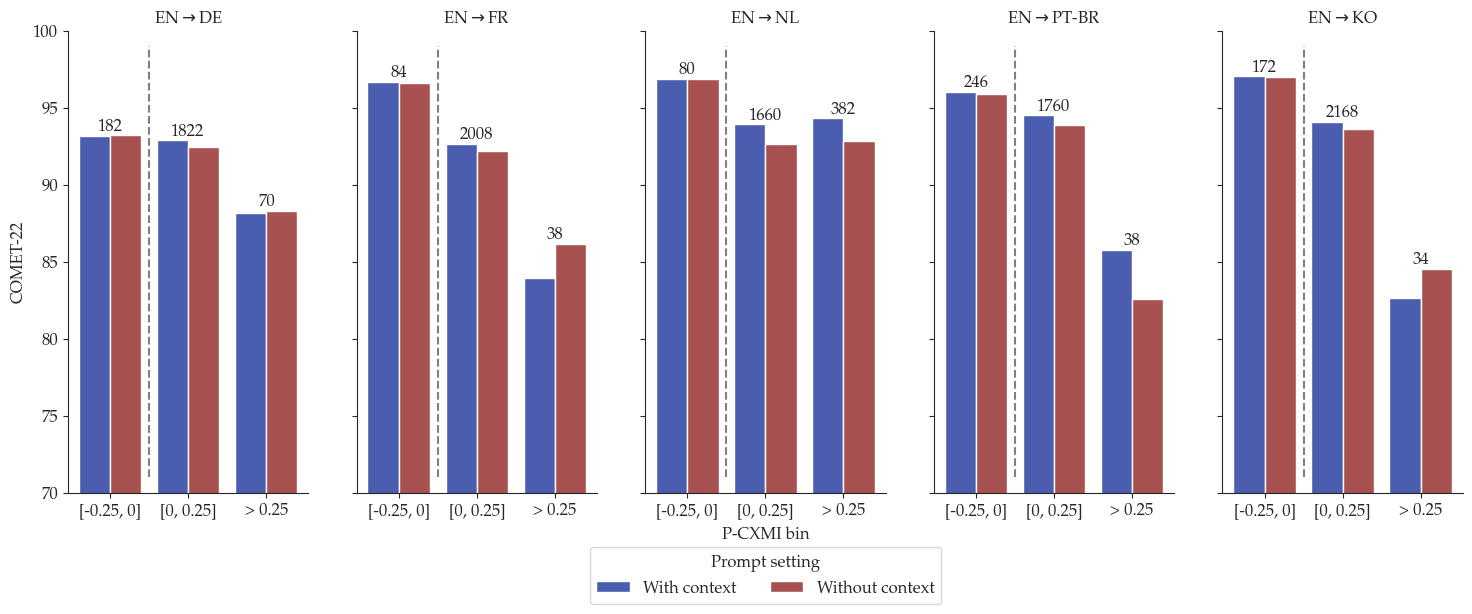

/mnt/data/jpombal/tmp/ipykernel_1583146/2939283796.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, bin_col_name] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_1583146/2939283796.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_1583146/2939283796.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and

pcxmi_fc_nc_on_nc


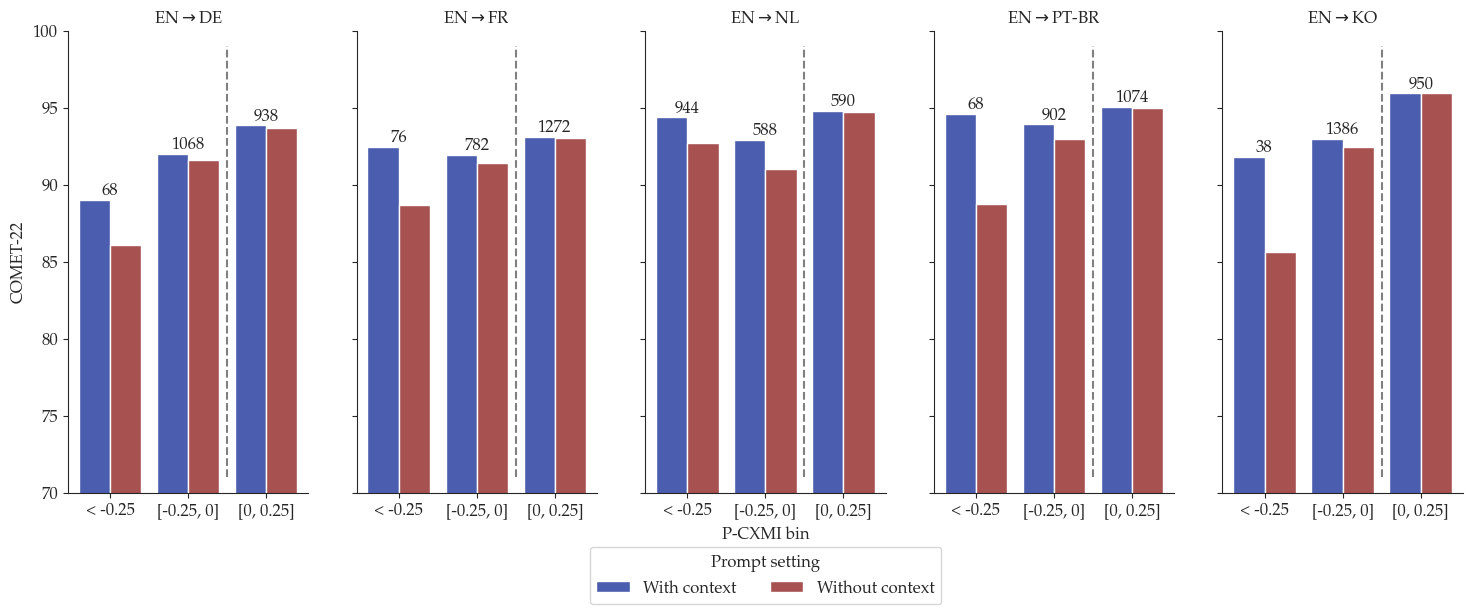

/mnt/data/jpombal/tmp/ipykernel_1583146/2939283796.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, bin_col_name] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_1583146/2939283796.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_1583146/2939283796.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and

pcxmi_diff


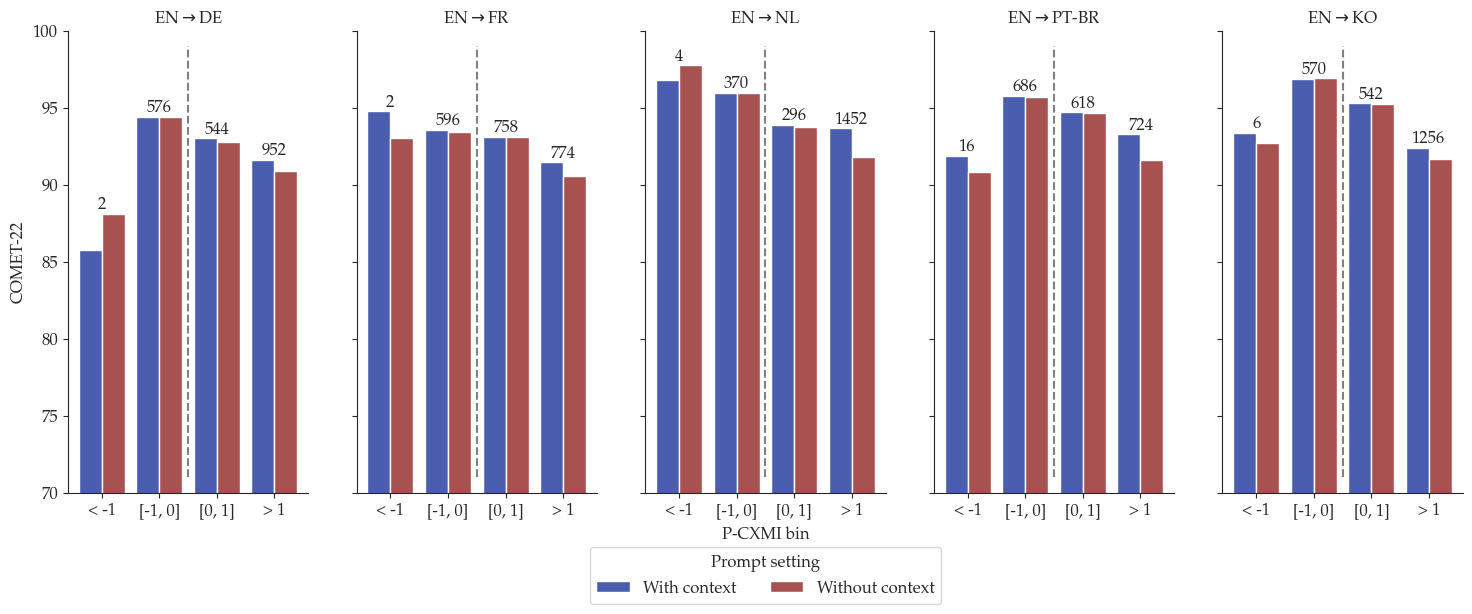

/mnt/data/jpombal/tmp/ipykernel_1583146/2939283796.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, bin_col_name] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_1583146/2939283796.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_1583146/2939283796.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and

lhood_diff


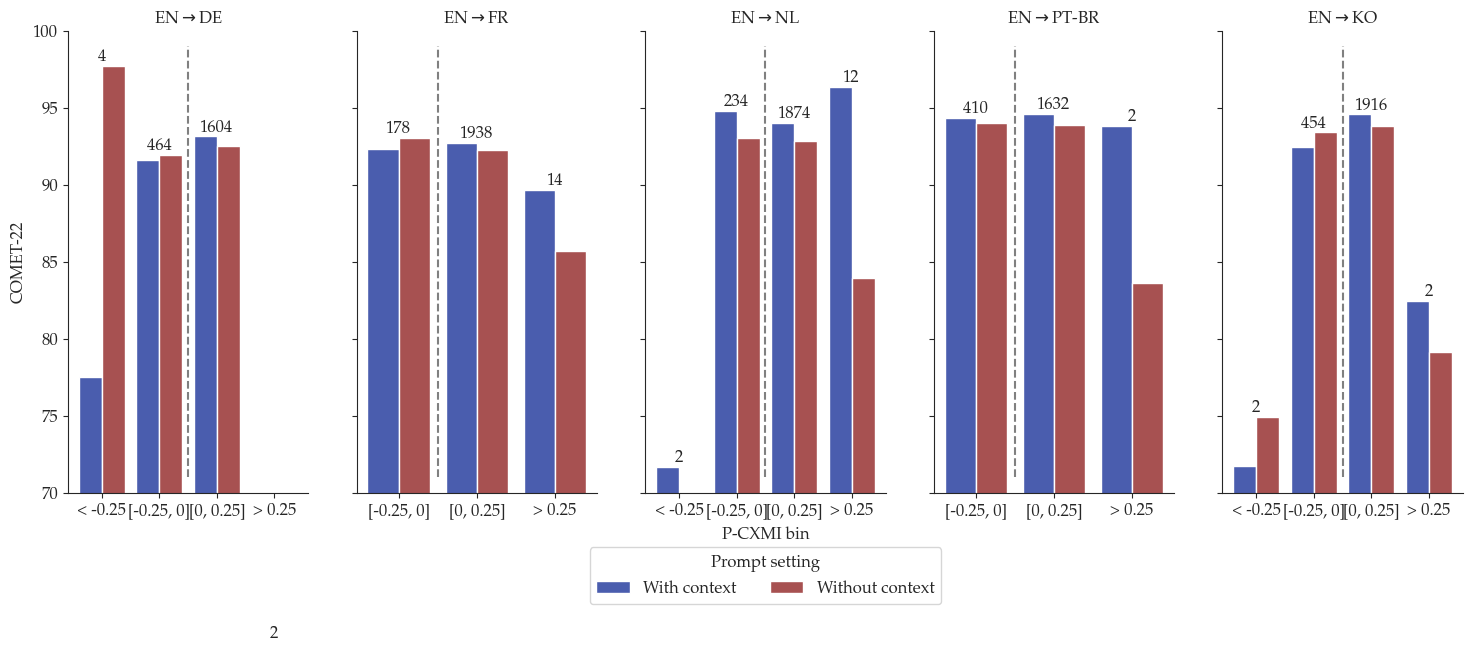

In [6]:
plot_df = df[df["lp"].str.startswith("en-")]
cmap = sns.color_palette(["#3953BF", "#b54343"])


for pcxmi_variant in pcxmi_variants:
    if pcxmi_variant == "pcxmi_diff":
        order = [
            "< -1",
            "[-1, 0]",
            "[0, 1]",
            "> 1",
        ]
        bins = [-float("inf"), -1, 0, 1, float("inf")]
    else:
        order = [
            "< -0.25",
            "[-0.25, 0]",
            "[0, 0.25]",
            "> 0.25",
        ]
        bins = [-float("inf"), -0.25, 0, 0.25, float("inf")]
    bin_col_name = f"{pcxmi_variant}_bin"
    # create
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(18, 6), sharey=True)

    dfs_by_lp = {}
    for lp, ax in zip(
        ["en-de", "en-fr", "en-nl", "en-pt-br", "en-ko"], [ax1, ax2, ax3, ax4, ax5]
    ):
        if lp != "en-pt-br":
            xx = lp.split("-")[1].upper()
        else:
            xx = "PT-BR"
        temp_df = plot_df[plot_df["lp"] == lp]
        # cut in pcxmi bins
        temp_df.loc[:, bin_col_name] = pd.cut(
            temp_df[f"{pcxmi_variant}"],
            bins=bins,
            labels=order,
        )
        # Convert DataFrames into long format
        temp_df = pd.melt(
            temp_df,
            id_vars=[bin_col_name],
            value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
            var_name="model",
            value_name="comet",
        )
        temp_df["comet"] = 100 * temp_df["comet"]
        # Plot for en-xx language pairs
        sns.barplot(
            ax=ax,
            data=temp_df,
            x=bin_col_name,
            y="comet",
            hue="model",
            errorbar=None,
            hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
            palette=cmap,
            legend=True if ax == ax3 else False,
            order=order,
        )
        sns.despine(ax=ax, right=True, left=False)
        ax.set_title(rf"EN$\rightarrow${xx}", fontsize=12)
        # ax.set_xticklabels(order)
        if ax == ax3:
            ax.set_xlabel("P-CXMI bin", fontsize=12)
        else:
            ax.set_xlabel("")
        ax.set_ylabel("COMET-22", fontsize=12)
        ax.tick_params(axis="both", which="major", labelsize=12)
        if ax != ax1:
            ax.set_ylabel("")
        ax.vlines(x=[1.5], ymin=71, ymax=99, color="gray", linestyle="--")
        ax.set_ylim(70, 100)
        # Calculate counts and mean heights for xx-en
        counts = temp_df.groupby(bin_col_name).size()
        means = temp_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()
        # Add counts to the xx-en plot
        for i, bin_label in enumerate(order):
            if bin_label in counts.index:
                count = counts[bin_label]
                max_mean_height = means.loc[bin_label].max()
                ax.text(
                    i,
                    max_mean_height,
                    f"{count}",
                    ha="center",
                    va="bottom",
                    fontsize=12,
                )

    # ax1.annotate(
    #     "Improvement\nin quality\nfrom adding\ncontext.",
    #     xy=(0.75, 93.1),  # point to which the arrow will point
    #     xytext=(-0.4, 94),  # position of the text
    #     arrowprops=dict(
    #         arrowstyle="->", color="black", connectionstyle="arc3,rad=0.2"  # arrow style
    #     ),
    #     fontsize=10,
    #     color="black",
    #     ha="left",
    # )

    # change legend title to "Prompt setting", with handles "With context" and "Without context"
    handles, labels = ax3.get_legend_handles_labels()
    ax3.legend(
        handles=handles,
        labels=["With context", "Without context"],
        title="Prompt setting",
        title_fontsize=12,
        bbox_to_anchor=(0.5, -0.1),
        fontsize=12,
        loc="upper center",
        ncol=2,
    )
    plt.savefig(
        f"../plots/{pcxmi_variant}_bins_context_hyp_lps_en_xx_{pcxmi_model}.pdf",
        bbox_inches="tight",
    )
    print(pcxmi_variant)
    plt.show()

### xx-en

/mnt/data/jpombal/tmp/ipykernel_1583146/2582859558.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, bin_col_name] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_1583146/2582859558.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_1583146/2582859558.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and

/mnt/data/jpombal/tmp/ipykernel_1583146/2582859558.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_1583146/2582859558.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = temp_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()
/mnt/data/jpombal/tmp/ipykernel_1583146/2582859558.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stab

pcxmi_fc_nc_on_fc


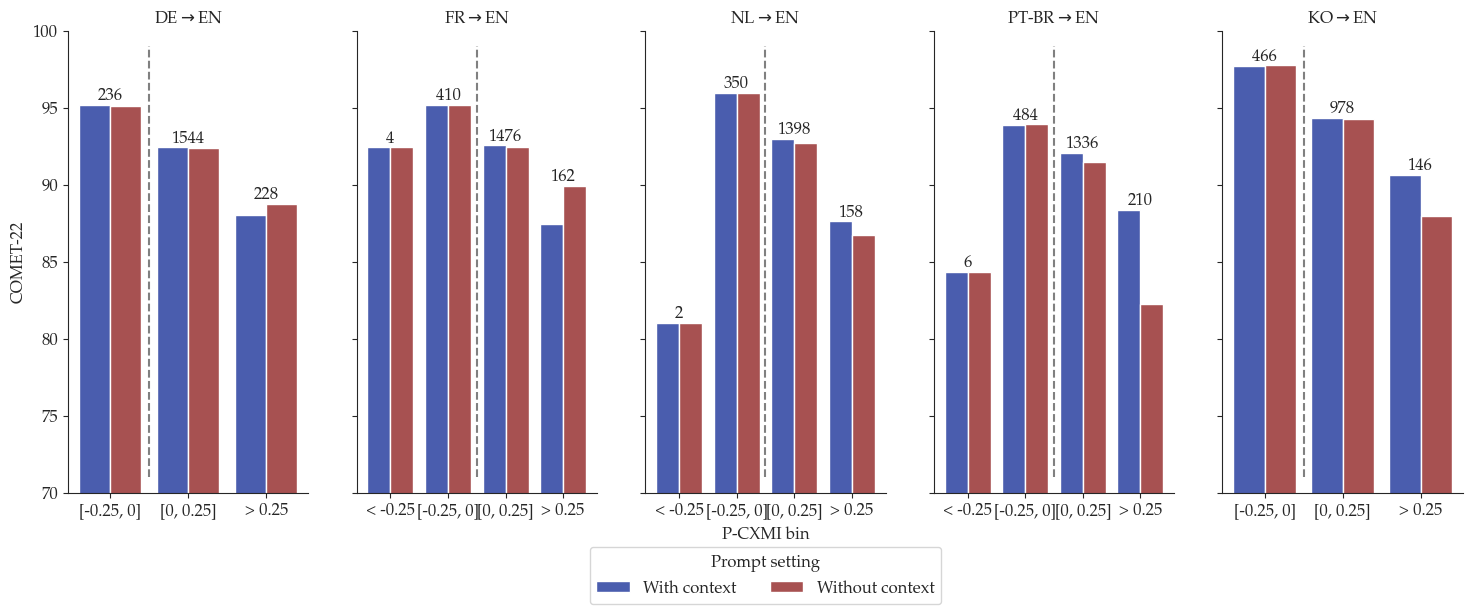

/mnt/data/jpombal/tmp/ipykernel_1583146/2582859558.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, bin_col_name] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_1583146/2582859558.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_1583146/2582859558.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and

pcxmi_fc_nc_on_nc


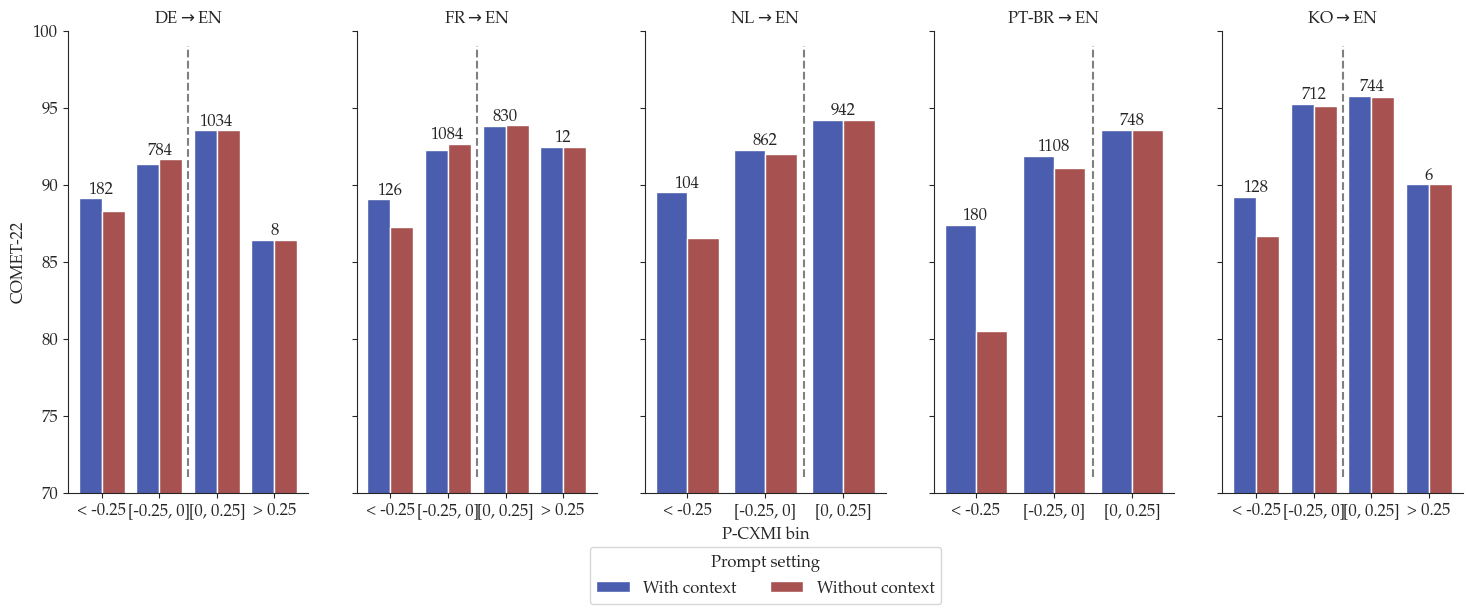

/mnt/data/jpombal/tmp/ipykernel_1583146/2582859558.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, bin_col_name] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_1583146/2582859558.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_1583146/2582859558.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and

pcxmi_diff


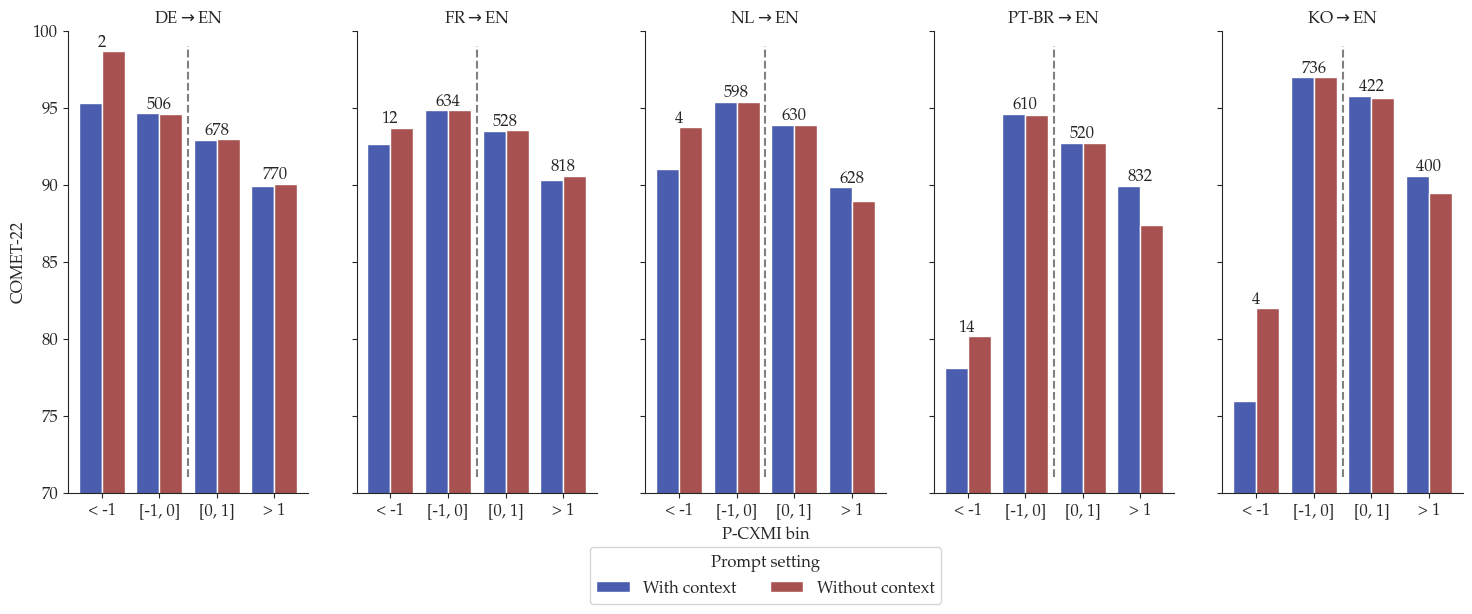

/mnt/data/jpombal/tmp/ipykernel_1583146/2582859558.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, bin_col_name] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_1583146/2582859558.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_1583146/2582859558.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and

lhood_diff


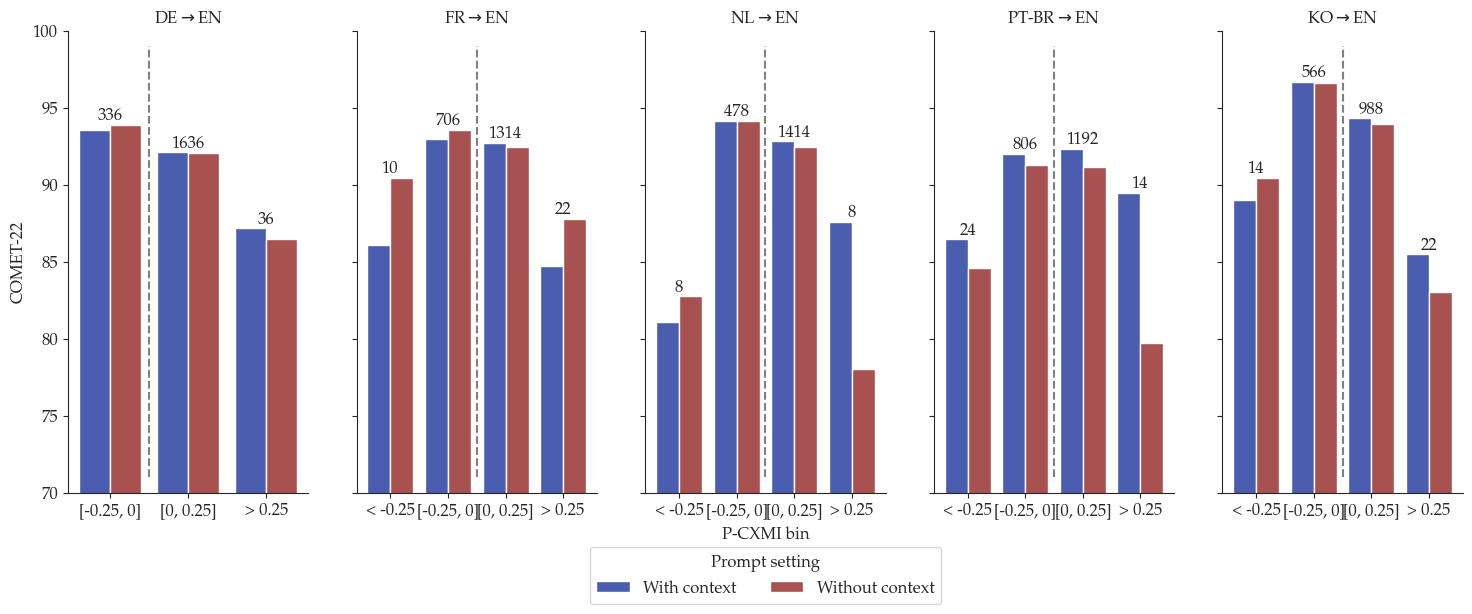

In [7]:
plot_df = df[df["lp"].str.endswith("-en")]
cmap = sns.color_palette(["#3953BF", "#b54343"])

for pcxmi_variant in pcxmi_variants:
    if pcxmi_variant == "pcxmi_diff":
        order = [
            "< -1",
            "[-1, 0]",
            "[0, 1]",
            "> 1",
        ]
        bins = [-float("inf"), -1, 0, 1, float("inf")]
    else:
        order = [
            "< -0.25",
            "[-0.25, 0]",
            "[0, 0.25]",
            "> 0.25",
        ]
        bins = [-float("inf"), -0.25, 0, 0.25, float("inf")]
    bin_col_name = f"{pcxmi_variant}_bin"
    # create
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(18, 6), sharey=True)

    dfs_by_lp = {}
    for lp, ax in zip(
        ["de-en", "fr-en", "nl-en", "pt-br-en", "ko-en"], [ax1, ax2, ax3, ax4, ax5]
    ):
        if lp != "pt-br-en":
            xx = lp.split("-")[0].upper()
        else:
            xx = "PT-BR"
        temp_df = plot_df[plot_df["lp"] == lp]
        # cut in pcxmi bins
        temp_df.loc[:, bin_col_name] = pd.cut(
            temp_df[f"{pcxmi_variant}"],
            bins=bins,
            labels=order,
        )
        # Convert DataFrames into long format
        temp_df = pd.melt(
            temp_df,
            id_vars=[bin_col_name],
            value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
            var_name="model",
            value_name="comet",
        )
        temp_df["comet"] = 100 * temp_df["comet"]
        # Plot for en-xx language pairs
        sns.barplot(
            ax=ax,
            data=temp_df,
            x=bin_col_name,
            y="comet",
            hue="model",
            errorbar=None,
            hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
            palette=cmap,
            legend=True if ax == ax3 else False,
            order=order,
        )
        sns.despine(ax=ax, right=True, left=False)
        ax.set_title(rf"{xx}$\rightarrow$EN", fontsize=12)
        # ax.set_xticklabels(order)
        if ax == ax3:
            ax.set_xlabel("P-CXMI bin", fontsize=12)
        else:
            ax.set_xlabel("")
        ax.set_ylabel("COMET-22", fontsize=12)
        ax.tick_params(axis="both", which="major", labelsize=12)
        if ax != ax1:
            ax.set_ylabel("")
        ax.vlines(x=[1.5], ymin=71, ymax=99, color="gray", linestyle="--")
        ax.set_ylim(70, 100)
        # Calculate counts and mean heights for xx-en
        counts = temp_df.groupby(bin_col_name).size()
        means = temp_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()
        # Add counts to the xx-en plot
        for i, bin_label in enumerate(order):
            if bin_label in counts.index:
                count = counts[bin_label]
                max_mean_height = means.loc[bin_label].max()
                ax.text(
                    i,
                    max_mean_height,
                    f"{count}",
                    ha="center",
                    va="bottom",
                    fontsize=12,
                )

    # ax1.annotate(
    #     "Improvement\nin quality\nfrom adding\ncontext.",
    #     xy=(0.75, 93.1),  # point to which the arrow will point
    #     xytext=(-0.4, 94),  # position of the text
    #     arrowprops=dict(
    #         arrowstyle="->", color="black", connectionstyle="arc3,rad=0.2"  # arrow style
    #     ),
    #     fontsize=10,
    #     color="black",
    #     ha="left",
    # )

    # change legend title to "Prompt setting", with handles "With context" and "Without context"
    handles, labels = ax3.get_legend_handles_labels()
    ax3.legend(
        handles=handles,
        labels=["With context", "Without context"],
        title="Prompt setting",
        title_fontsize=12,
        bbox_to_anchor=(0.5, -0.1),
        fontsize=12,
        loc="upper center",
        ncol=2,
    )
    plt.savefig(
        f"../plots/{pcxmi_variant}_bins_context_hyp_lps_xx_en_{pcxmi_model}.pdf",
        bbox_inches="tight",
    )
    print(pcxmi_variant)
    plt.show()

# aggregate all lps

/mnt/data/jpombal/tmp/ipykernel_1583146/2479301262.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = plot_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_1583146/2479301262.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = plot_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()


pcxmi_fc_nc_on_fc


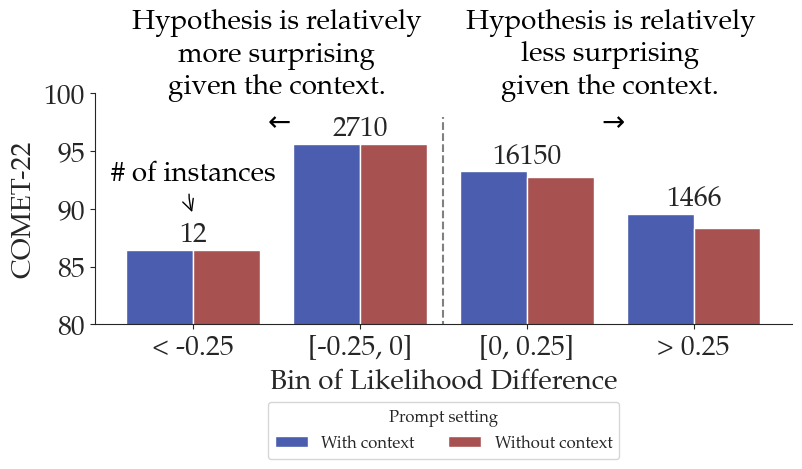

/mnt/data/jpombal/tmp/ipykernel_1583146/2479301262.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = plot_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_1583146/2479301262.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = plot_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()


pcxmi_fc_nc_on_nc


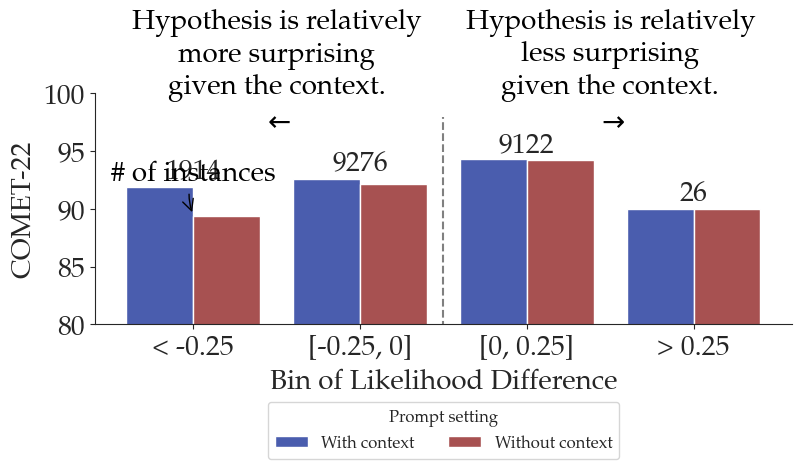

/mnt/data/jpombal/tmp/ipykernel_1583146/2479301262.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = plot_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_1583146/2479301262.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = plot_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()


pcxmi_diff


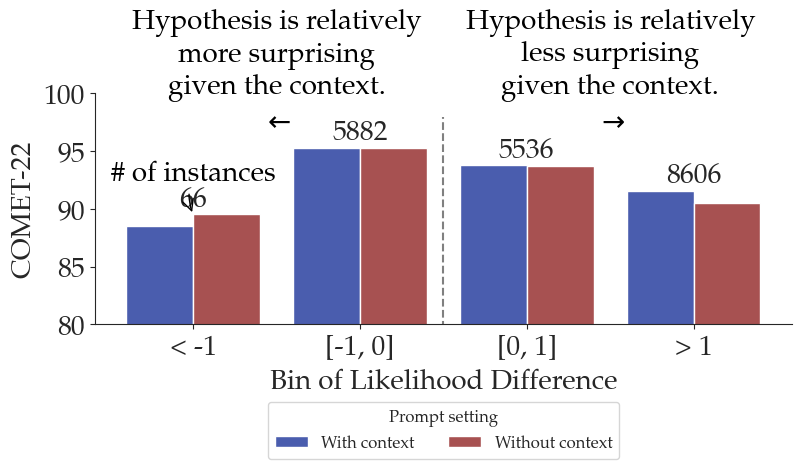

/mnt/data/jpombal/tmp/ipykernel_1583146/2479301262.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = plot_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_1583146/2479301262.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = plot_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()


lhood_diff


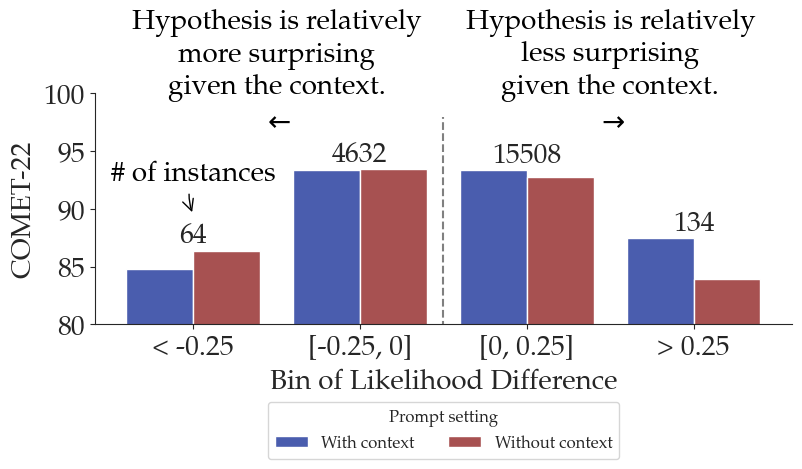

In [12]:
cmap = sns.color_palette(["#3953BF", "#b54343"])
for pcxmi_variant in pcxmi_variants:
    if pcxmi_variant == "pcxmi_diff":
        order = [
            "< -1",
            "[-1, 0]",
            "[0, 1]",
            "> 1",
        ]
        bins = [-float("inf"), -1, 0, 1, float("inf")]
    else:
        order = [
            "< -0.25",
            "[-0.25, 0]",
            "[0, 0.25]",
            "> 0.25",
        ]
        bins = [-float("inf"), -0.25, 0, 0.25, float("inf")]
    fig, ax = plt.subplots(figsize=(9, 3))
    plot_df = df.copy()
    # cut in pcxmi bins
    plot_df.loc[:, bin_col_name] = pd.cut(
        plot_df[pcxmi_variant],
        bins=bins,
        labels=order,
    )
    # Convert DataFrames into long format
    plot_df = pd.melt(
        plot_df,
        id_vars=[bin_col_name],
        value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
        var_name="model",
        value_name="comet",
    )
    plot_df["comet"] = 100 * plot_df["comet"]
    # Plot for en-xx language pairs
    sns.barplot(
        ax=ax,
        data=plot_df,
        x=bin_col_name,
        y="comet",
        hue="model",
        errorbar=None,
        hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
        palette=cmap,
        legend=True,
        order=order,
    )
    sns.despine(ax=ax, right=True, left=False)
    # ax.set_xticklabels(order)
    ax.set_xlabel("Bin of Likelihood Difference", fontsize=20)
    ax.set_ylabel("COMET-22", fontsize=20)
    ax.tick_params(axis="both", which="major", labelsize=20)
    ax.vlines(x=[1.5], ymin=72, ymax=98, color="gray", linestyle="--")
    ax.set_ylim(80, 100)
    # Calculate counts and mean heights for en-xx
    counts = plot_df.groupby(bin_col_name).size()
    means = plot_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()
    # Add counts to the xx-en plot
    for i, bin_label in enumerate(order):
        if bin_label in counts.index:
            count = counts[bin_label]
            max_mean_height = means.loc[bin_label].max()
            ax.text(
                i,
                max_mean_height,
                f"{count}",
                ha="center",
                va="bottom",
                fontsize=20,
            )

    ax.annotate(
        "Hypothesis is relatively\nmore surprising\ngiven the context.",
        xy=(0.5, 100),  # position of the text
        fontsize=20,
        color="black",
        ha="center",
    )
    ax.annotate(
        r"$\leftarrow$",
        xy=(0.5, 97),  # position of the text
        fontsize=20,
        color="black",
        ha="center",
    )
    ax.annotate(
        "Hypothesis is relatively\nless surprising\ngiven the context.",
        xy=(2.5, 100),  # position of the text
        fontsize=20,
        color="black",
        ha="center",
    )
    ax.annotate(
        r"$\rightarrow$",
        xy=(2.5, 97),  # position of the text
        fontsize=20,
        color="black",
        ha="center",
    )

    # change legend title to "Prompt setting", with handles "With context" and "Without context"
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=handles,
        labels=["With context", "Without context"],
        title="Prompt setting",
        title_fontsize=12,
        bbox_to_anchor=(0.5, -0.3),
        fontsize=12,
        loc="upper center",
        ncol=2,
    )
    ax.set_yticks(range(80, 101, 5))
    ax.annotate(
        "# of instances",
        xy=(0, 89.5),  # point to which the arrow will point
        xytext=(0, 92.5),  # position of the text
        arrowprops=dict(
            arrowstyle="->",
            color="black",
            connectionstyle="arc3,rad=0.2",  # arrow style
        ),
        fontsize=20,
        color="black",
        ha="center",
    )
    plt.savefig(
        f"../plots/{pcxmi_variant}_bins_context_hyp_agg_{pcxmi_model}.pdf",
        bbox_inches="tight",
    )
    print(pcxmi_variant)
    plt.show()

# TOWER INSTRUCT

In [16]:
model = "greedy-7b"
pcxmi_model = "TowerInstruct-7B-v0.2"
dataset = "wmt24_chat_test"
df["context_helps"] = df.apply(
    lambda x: (
        1
        if x[f"{model}-w-context-comet"] > x[f"{model}-wo-context-comet"]
        else 0 if x[f"{model}-w-context-comet"] < x[f"{model}-wo-context-comet"] else -1
    ),
    axis=1,
)
# break df in the comet bins: [0, 0.3], [0.3, 0.4], [0.4, 0.5], [0.5, 0.6], [0.6, 0.7], [0.7, 0.8], [0.8, 0.9], [0.9, 1]
df["comet_bin"] = pd.cut(
    df[f"{model}-wo-context-comet"],
    bins=[0, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    labels=[
        "[0, 0.5]",
        "[0.5, 0.6]",
        "[0.6, 0.7]",
        "[0.7, 0.8]",
        "[0.8, 0.9]",
        "[0.9, 1]",
    ],
)
print(df["comet_bin"].value_counts())
df.groupby(by="lp")["context_helps"].value_counts(normalize=True)

comet_bin
[0.9, 1]      7353
[0.8, 0.9]    2128
[0.7, 0.8]     470
[0.6, 0.7]     147
[0.5, 0.6]      59
[0, 0.5]        12
Name: count, dtype: int64


lp        context_helps
de-en     -1               0.443227
           0               0.325697
           1               0.231076
en-de     -1               0.390550
           0               0.317261
           1               0.292189
en-fr     -1               0.367136
           0               0.339906
           1               0.292958
en-ko      0               0.419545
           1               0.348778
          -1               0.231676
en-nl      1               0.403393
           0               0.317625
          -1               0.278982
en-pt-br  -1               0.384540
           0               0.338552
           1               0.276908
fr-en     -1               0.442495
           0               0.311891
           1               0.245614
ko-en     -1               0.495597
           0               0.301887
           1               0.202516
nl-en     -1               0.433962
           0               0.285115
           1               0.280922
pt-b

In [17]:
from tower_eval.utils import read_lines

df["pcxmi_fc_nc_on_fc"] = 0.0  # classic pcxmi
df["pcxmi_fc_nc_on_nc"] = 0.0  # for pcxmi diff
df["lhood_diff"] = 0.0  # what we had in the paper

for lp in [
    "en-de",
    "en-fr",
    "en-nl",
    "en-pt-br",
    "en-ko",
    "de-en",
    "fr-en",
    "nl-en",
    "pt-br-en",
    "ko-en",
]:
    log_probs_fc_on_fc = [
        float(l)
        for l in read_lines(
            f"../pcxmi_hyps/full_context_input_on_full_context_output/mt/{dataset}.{lp}/{pcxmi_model}/mean_log_probs.txt"
        )
    ]
    log_probs_fc_on_nc = [
        float(l)
        for l in read_lines(
            f"../pcxmi_hyps/full_context_input_on_no_context_output/mt/{dataset}.{lp}/{pcxmi_model}/mean_log_probs.txt"
        )
    ]
    log_probs_nc_on_nc = [
        float(l)
        for l in read_lines(
            f"../pcxmi_hyps/no_context_input_on_no_context_output/mt/{dataset}.{lp}/{pcxmi_model}/mean_log_probs.txt"
        )
    ]
    log_probs_nc_on_fc = [
        float(l)
        for l in read_lines(
            f"../pcxmi_hyps/no_context_input_on_full_context_output/mt/{dataset}.{lp}/{pcxmi_model}/mean_log_probs.txt"
        )
    ]

    df.loc[(df["lp"] == lp), "pcxmi_fc_nc_on_fc"] = [
        w - wo for w, wo in zip(log_probs_fc_on_fc, log_probs_nc_on_fc)
    ]
    df.loc[(df["lp"] == lp), "pcxmi_fc_nc_on_nc"] = [
        w - wo for w, wo in zip(log_probs_fc_on_nc, log_probs_nc_on_nc)
    ]
    df.loc[(df["lp"] == lp), "pcxmi_diff"] = (
        df.loc[(df["lp"] == lp), "pcxmi_fc_nc_on_fc"]
        - df.loc[(df["lp"] == lp), "pcxmi_fc_nc_on_nc"]
    ) / df.loc[(df["lp"] == lp), "pcxmi_fc_nc_on_fc"]
    df.loc[(df["lp"] == lp), "lhood_diff"] = [
        w - wo for w, wo in zip(log_probs_fc_on_fc, log_probs_nc_on_nc)
    ]
pcxmi_variants = ["pcxmi_fc_nc_on_fc", "pcxmi_fc_nc_on_nc", "pcxmi_diff", "lhood_diff"]

/mnt/data/jpombal/tmp/ipykernel_250278/774561354.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, bin_col_name] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_250278/774561354.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_250278/774561354.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silen

pcxmi_fc_nc_on_fc


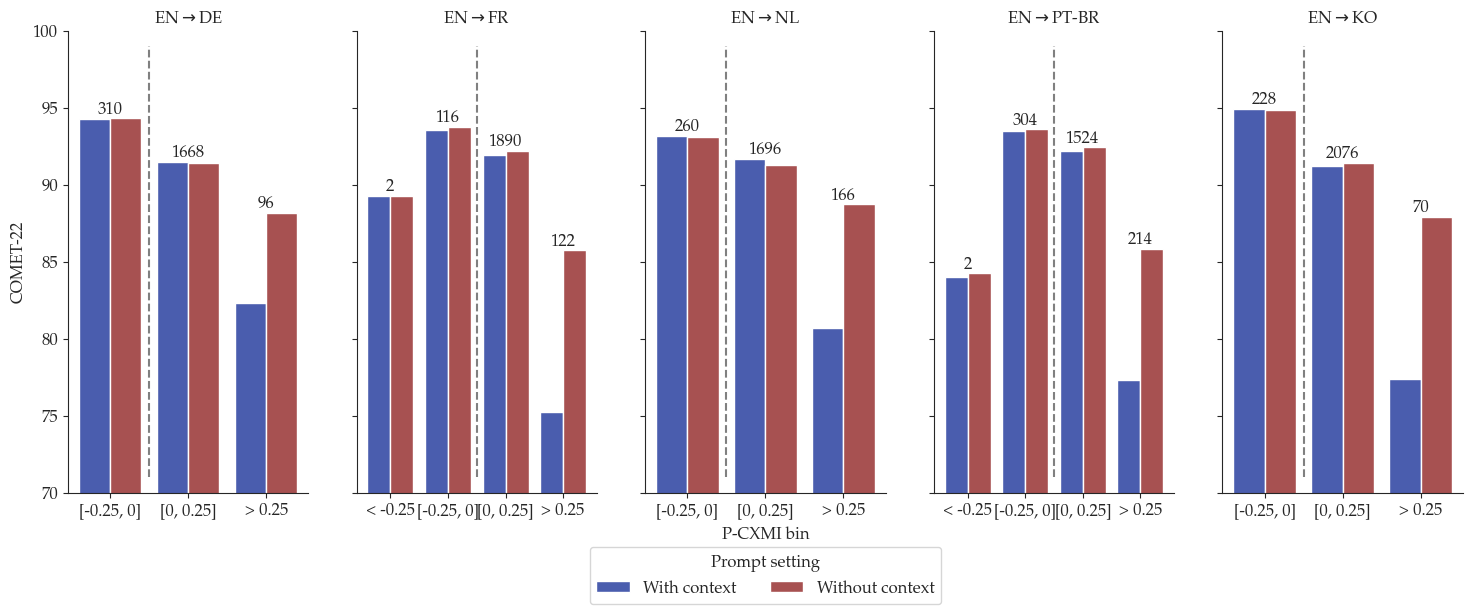

/mnt/data/jpombal/tmp/ipykernel_250278/774561354.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, bin_col_name] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_250278/774561354.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_250278/774561354.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silen

pcxmi_fc_nc_on_nc


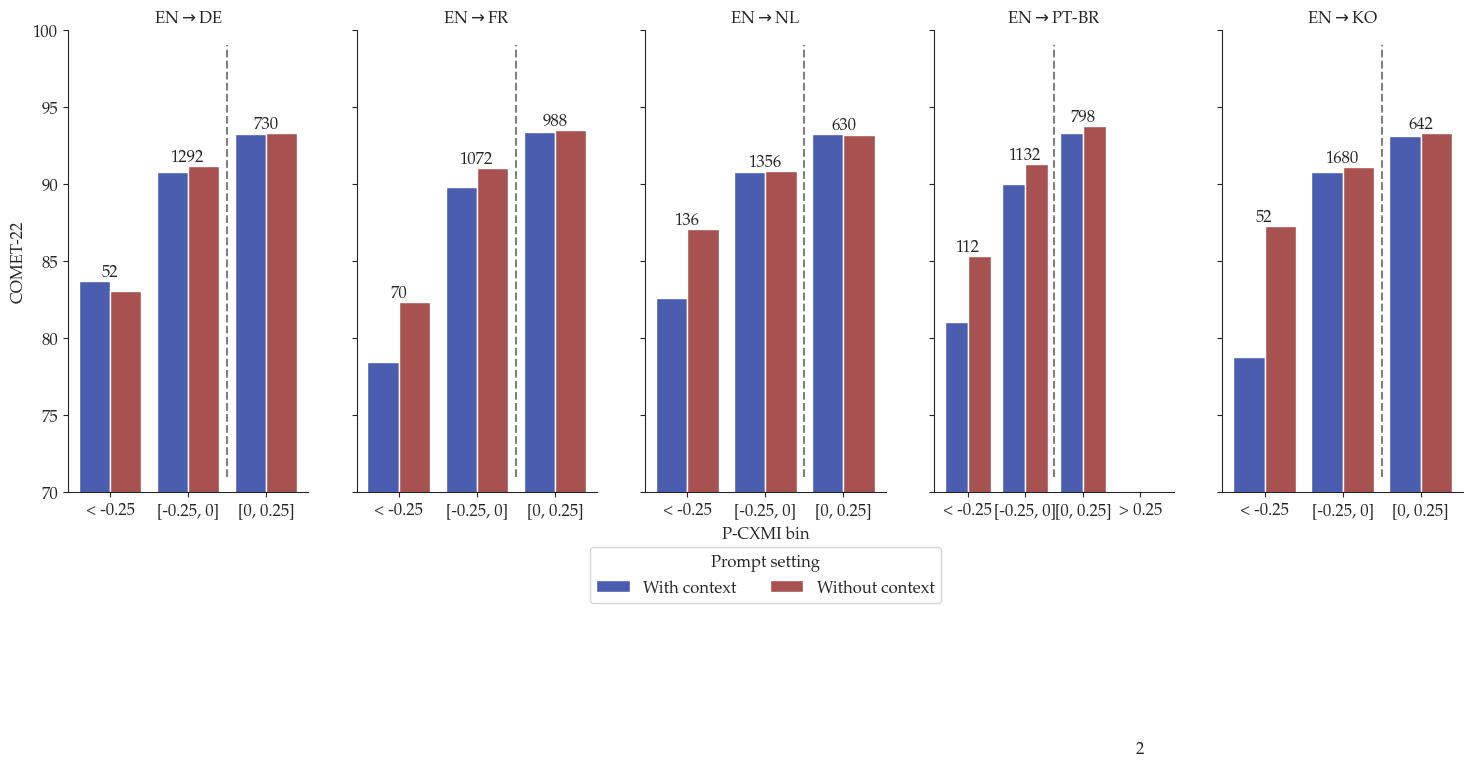

/mnt/data/jpombal/tmp/ipykernel_250278/774561354.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, bin_col_name] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_250278/774561354.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_250278/774561354.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silen

pcxmi_diff


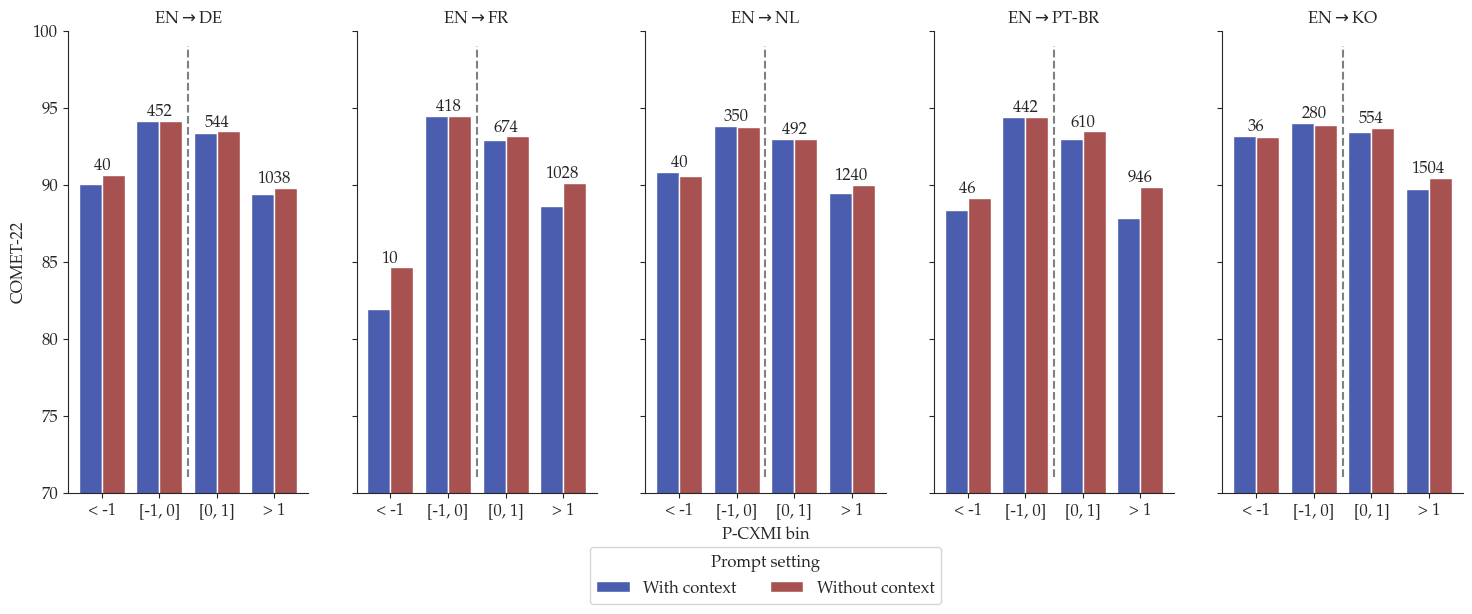

/mnt/data/jpombal/tmp/ipykernel_250278/774561354.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, bin_col_name] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_250278/774561354.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_250278/774561354.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silen

lhood_diff


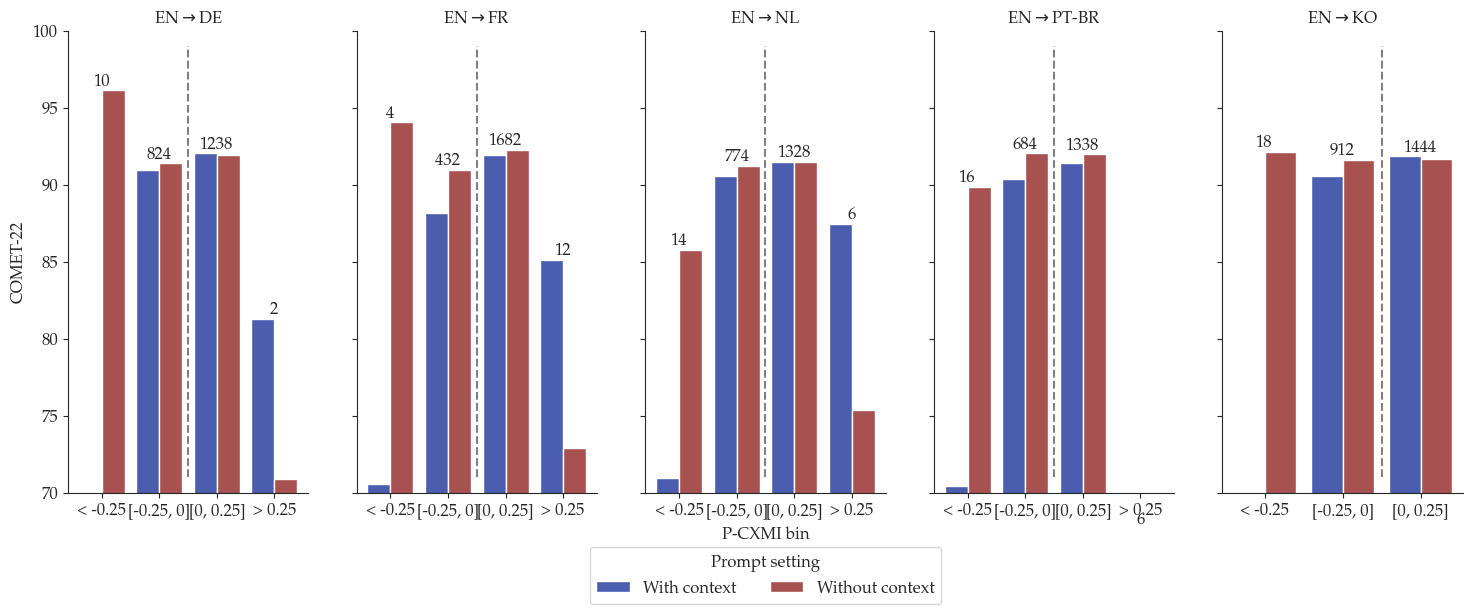

In [18]:
plot_df = df[df["lp"].str.startswith("en-")]
cmap = sns.color_palette(["#3953BF", "#b54343"])


for pcxmi_variant in pcxmi_variants:
    if pcxmi_variant == "pcxmi_diff":
        order = [
            "< -1",
            "[-1, 0]",
            "[0, 1]",
            "> 1",
        ]
        bins = [-float("inf"), -1, 0, 1, float("inf")]
    else:
        order = [
            "< -0.25",
            "[-0.25, 0]",
            "[0, 0.25]",
            "> 0.25",
        ]
        bins = [-float("inf"), -0.25, 0, 0.25, float("inf")]
    bin_col_name = f"{pcxmi_variant}_bin"
    # create
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(18, 6), sharey=True)

    dfs_by_lp = {}
    for lp, ax in zip(
        ["en-de", "en-fr", "en-nl", "en-pt-br", "en-ko"], [ax1, ax2, ax3, ax4, ax5]
    ):
        if lp != "en-pt-br":
            xx = lp.split("-")[1].upper()
        else:
            xx = "PT-BR"
        temp_df = plot_df[plot_df["lp"] == lp]
        # cut in pcxmi bins
        temp_df.loc[:, bin_col_name] = pd.cut(
            temp_df[f"{pcxmi_variant}"],
            bins=bins,
            labels=order,
        )
        # Convert DataFrames into long format
        temp_df = pd.melt(
            temp_df,
            id_vars=[bin_col_name],
            value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
            var_name="model",
            value_name="comet",
        )
        temp_df["comet"] = 100 * temp_df["comet"]
        # Plot for en-xx language pairs
        sns.barplot(
            ax=ax,
            data=temp_df,
            x=bin_col_name,
            y="comet",
            hue="model",
            errorbar=None,
            hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
            palette=cmap,
            legend=True if ax == ax3 else False,
            order=order,
        )
        sns.despine(ax=ax, right=True, left=False)
        ax.set_title(rf"EN$\rightarrow${xx}", fontsize=12)
        # ax.set_xticklabels(order)
        if ax == ax3:
            ax.set_xlabel("P-CXMI bin", fontsize=12)
        else:
            ax.set_xlabel("")
        ax.set_ylabel("COMET-22", fontsize=12)
        ax.tick_params(axis="both", which="major", labelsize=12)
        if ax != ax1:
            ax.set_ylabel("")
        ax.vlines(x=[1.5], ymin=71, ymax=99, color="gray", linestyle="--")
        ax.set_ylim(70, 100)
        # Calculate counts and mean heights for xx-en
        counts = temp_df.groupby(bin_col_name).size()
        means = temp_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()
        # Add counts to the xx-en plot
        for i, bin_label in enumerate(order):
            if bin_label in counts.index:
                count = counts[bin_label]
                max_mean_height = means.loc[bin_label].max()
                ax.text(
                    i,
                    max_mean_height,
                    f"{count}",
                    ha="center",
                    va="bottom",
                    fontsize=12,
                )

    # ax1.annotate(
    #     "Improvement\nin quality\nfrom adding\ncontext.",
    #     xy=(0.75, 93.1),  # point to which the arrow will point
    #     xytext=(-0.4, 94),  # position of the text
    #     arrowprops=dict(
    #         arrowstyle="->", color="black", connectionstyle="arc3,rad=0.2"  # arrow style
    #     ),
    #     fontsize=10,
    #     color="black",
    #     ha="left",
    # )

    # change legend title to "Prompt setting", with handles "With context" and "Without context"
    handles, labels = ax3.get_legend_handles_labels()
    ax3.legend(
        handles=handles,
        labels=["With context", "Without context"],
        title="Prompt setting",
        title_fontsize=12,
        bbox_to_anchor=(0.5, -0.1),
        fontsize=12,
        loc="upper center",
        ncol=2,
    )
    plt.savefig(
        f"../plots/{pcxmi_variant}_bins_context_hyp_lps_xx_en_{pcxmi_model}.pdf",
        bbox_inches="tight",
    )
    print(pcxmi_variant)
    plt.show()

/mnt/data/jpombal/tmp/ipykernel_250278/2582859558.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, bin_col_name] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_250278/2582859558.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_250278/2582859558.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and si

pcxmi_fc_nc_on_fc


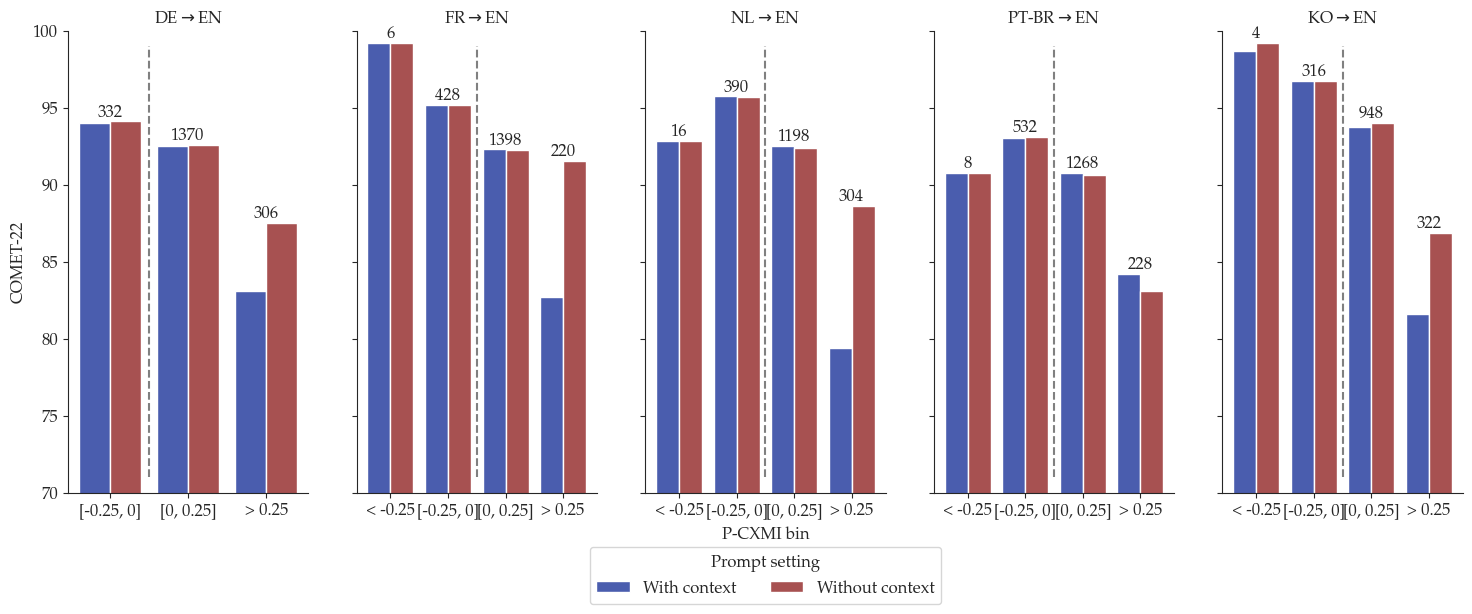

/mnt/data/jpombal/tmp/ipykernel_250278/2582859558.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, bin_col_name] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_250278/2582859558.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_250278/2582859558.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and si

pcxmi_fc_nc_on_nc


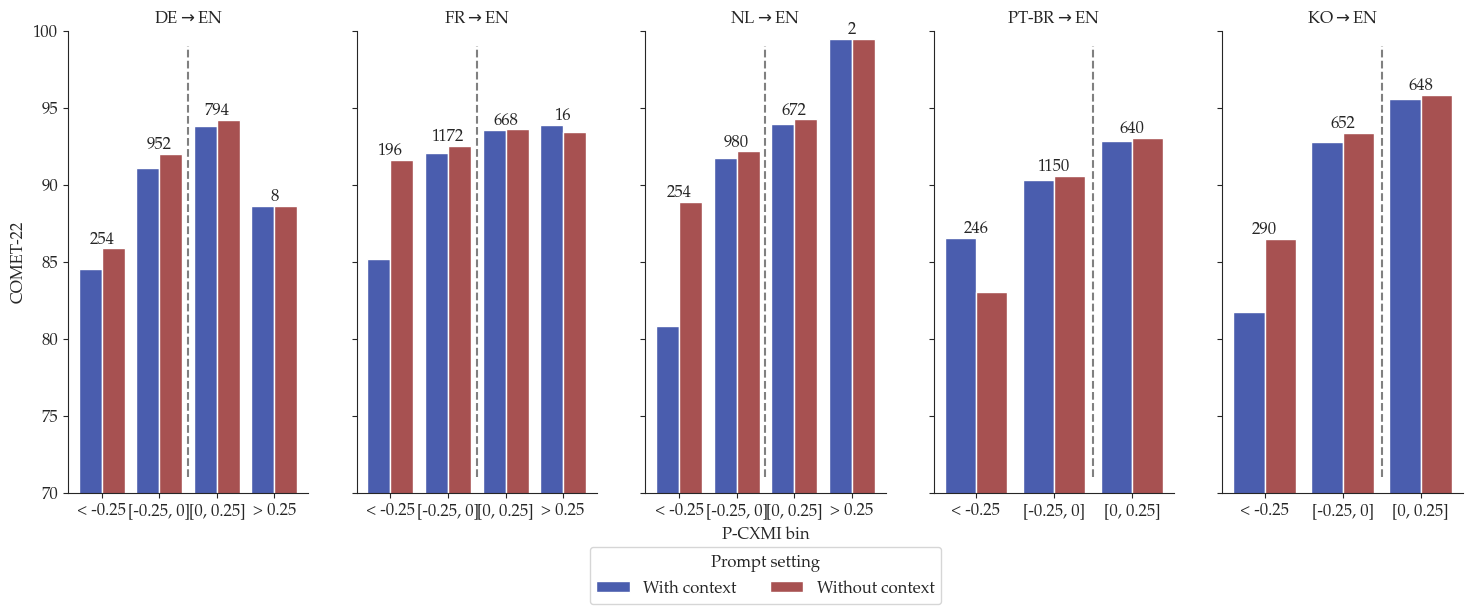

/mnt/data/jpombal/tmp/ipykernel_250278/2582859558.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, bin_col_name] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_250278/2582859558.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_250278/2582859558.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and si

pcxmi_diff


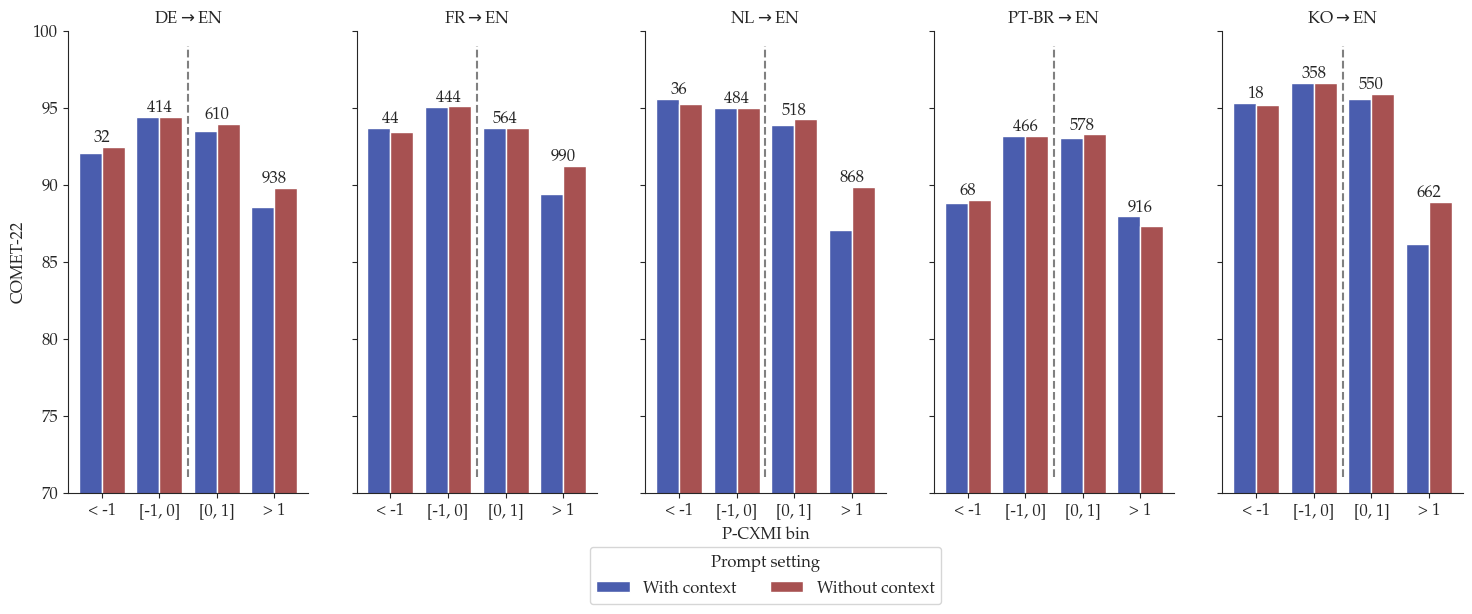

/mnt/data/jpombal/tmp/ipykernel_250278/2582859558.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.loc[:, bin_col_name] = pd.cut(
/mnt/data/jpombal/tmp/ipykernel_250278/2582859558.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = temp_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_250278/2582859558.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and si

lhood_diff


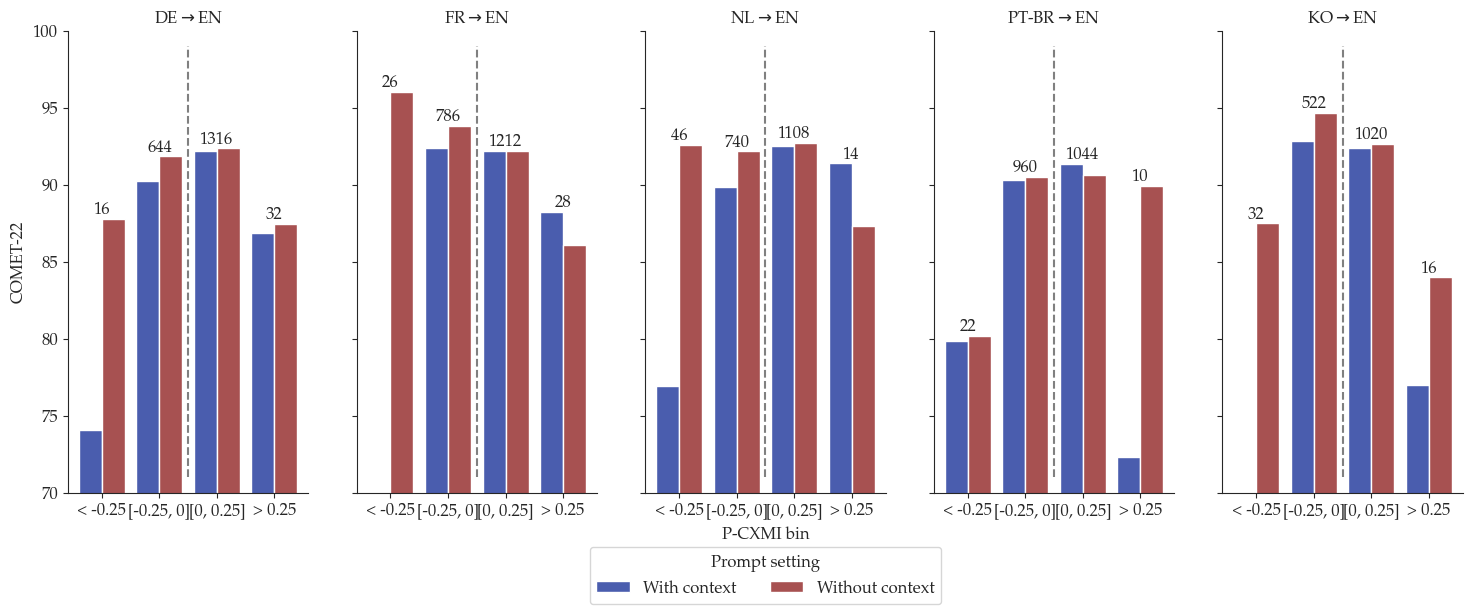

In [19]:
plot_df = df[df["lp"].str.endswith("-en")]
cmap = sns.color_palette(["#3953BF", "#b54343"])

for pcxmi_variant in pcxmi_variants:
    if pcxmi_variant == "pcxmi_diff":
        order = [
            "< -1",
            "[-1, 0]",
            "[0, 1]",
            "> 1",
        ]
        bins = [-float("inf"), -1, 0, 1, float("inf")]
    else:
        order = [
            "< -0.25",
            "[-0.25, 0]",
            "[0, 0.25]",
            "> 0.25",
        ]
        bins = [-float("inf"), -0.25, 0, 0.25, float("inf")]
    bin_col_name = f"{pcxmi_variant}_bin"
    # create
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(18, 6), sharey=True)

    dfs_by_lp = {}
    for lp, ax in zip(
        ["de-en", "fr-en", "nl-en", "pt-br-en", "ko-en"], [ax1, ax2, ax3, ax4, ax5]
    ):
        if lp != "pt-br-en":
            xx = lp.split("-")[0].upper()
        else:
            xx = "PT-BR"
        temp_df = plot_df[plot_df["lp"] == lp]
        # cut in pcxmi bins
        temp_df.loc[:, bin_col_name] = pd.cut(
            temp_df[f"{pcxmi_variant}"],
            bins=bins,
            labels=order,
        )
        # Convert DataFrames into long format
        temp_df = pd.melt(
            temp_df,
            id_vars=[bin_col_name],
            value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
            var_name="model",
            value_name="comet",
        )
        temp_df["comet"] = 100 * temp_df["comet"]
        # Plot for en-xx language pairs
        sns.barplot(
            ax=ax,
            data=temp_df,
            x=bin_col_name,
            y="comet",
            hue="model",
            errorbar=None,
            hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
            palette=cmap,
            legend=True if ax == ax3 else False,
            order=order,
        )
        sns.despine(ax=ax, right=True, left=False)
        ax.set_title(rf"{xx}$\rightarrow$EN", fontsize=12)
        # ax.set_xticklabels(order)
        if ax == ax3:
            ax.set_xlabel("P-CXMI bin", fontsize=12)
        else:
            ax.set_xlabel("")
        ax.set_ylabel("COMET-22", fontsize=12)
        ax.tick_params(axis="both", which="major", labelsize=12)
        if ax != ax1:
            ax.set_ylabel("")
        ax.vlines(x=[1.5], ymin=71, ymax=99, color="gray", linestyle="--")
        ax.set_ylim(70, 100)
        # Calculate counts and mean heights for xx-en
        counts = temp_df.groupby(bin_col_name).size()
        means = temp_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()
        # Add counts to the xx-en plot
        for i, bin_label in enumerate(order):
            if bin_label in counts.index:
                count = counts[bin_label]
                max_mean_height = means.loc[bin_label].max()
                ax.text(
                    i,
                    max_mean_height,
                    f"{count}",
                    ha="center",
                    va="bottom",
                    fontsize=12,
                )

    # ax1.annotate(
    #     "Improvement\nin quality\nfrom adding\ncontext.",
    #     xy=(0.75, 93.1),  # point to which the arrow will point
    #     xytext=(-0.4, 94),  # position of the text
    #     arrowprops=dict(
    #         arrowstyle="->", color="black", connectionstyle="arc3,rad=0.2"  # arrow style
    #     ),
    #     fontsize=10,
    #     color="black",
    #     ha="left",
    # )

    # change legend title to "Prompt setting", with handles "With context" and "Without context"
    handles, labels = ax3.get_legend_handles_labels()
    ax3.legend(
        handles=handles,
        labels=["With context", "Without context"],
        title="Prompt setting",
        title_fontsize=12,
        bbox_to_anchor=(0.5, -0.1),
        fontsize=12,
        loc="upper center",
        ncol=2,
    )
    plt.savefig(
        f"../plots/{pcxmi_variant}_bins_context_hyp_lps_xx_en_{pcxmi_model}.pdf",
        bbox_inches="tight",
    )
    print(pcxmi_variant)
    plt.show()

pcxmi_fc_nc_on_fc


/mnt/data/jpombal/tmp/ipykernel_250278/2643655822.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = plot_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_250278/2643655822.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = plot_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()


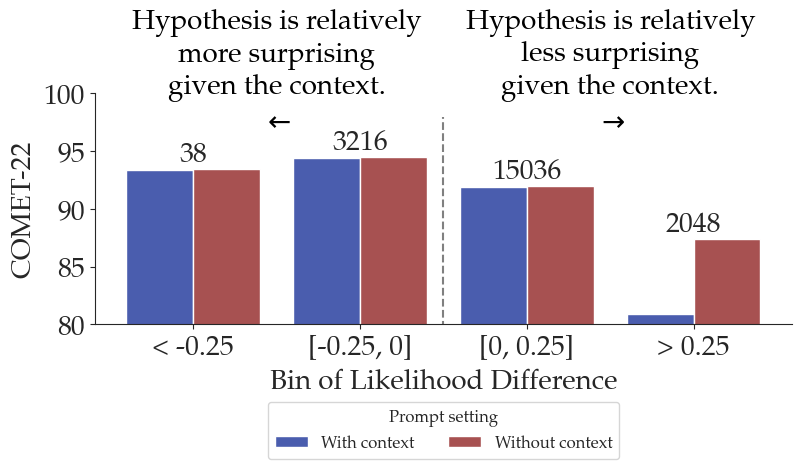

pcxmi_fc_nc_on_nc


/mnt/data/jpombal/tmp/ipykernel_250278/2643655822.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = plot_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_250278/2643655822.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = plot_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()


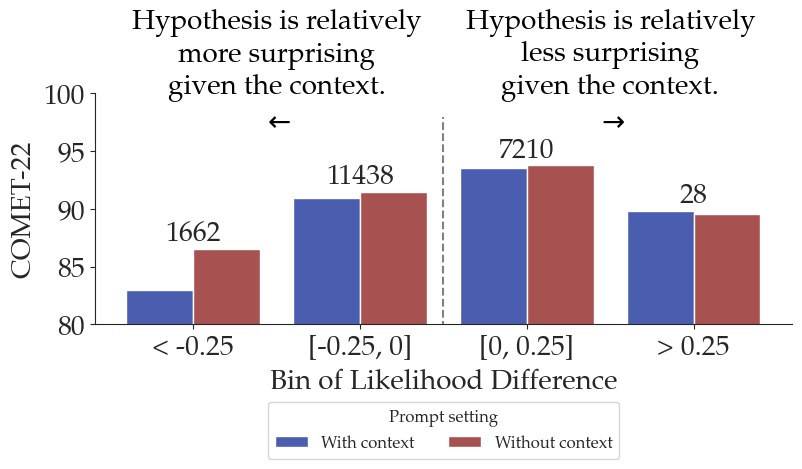

pcxmi_diff


/mnt/data/jpombal/tmp/ipykernel_250278/2643655822.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = plot_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_250278/2643655822.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = plot_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()


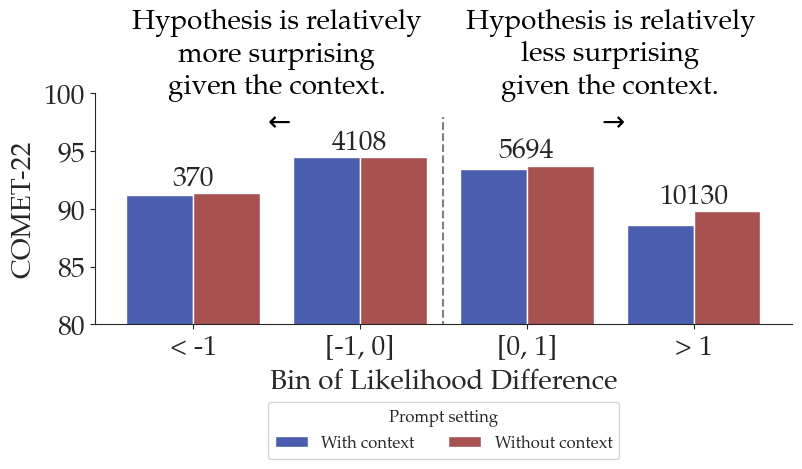

lhood_diff


/mnt/data/jpombal/tmp/ipykernel_250278/2643655822.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = plot_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_250278/2643655822.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = plot_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()


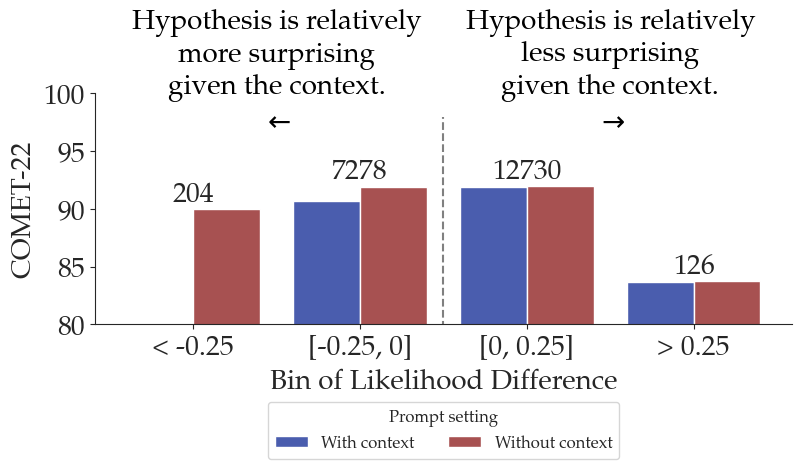

In [22]:
cmap = sns.color_palette(["#3953BF", "#b54343"])
for pcxmi_variant in pcxmi_variants:
    if pcxmi_variant == "pcxmi_diff":
        order = [
            "< -1",
            "[-1, 0]",
            "[0, 1]",
            "> 1",
        ]
        bins = [-float("inf"), -1, 0, 1, float("inf")]
    else:
        order = [
            "< -0.25",
            "[-0.25, 0]",
            "[0, 0.25]",
            "> 0.25",
        ]
        bins = [-float("inf"), -0.25, 0, 0.25, float("inf")]
    fig, ax = plt.subplots(figsize=(9, 3))
    plot_df = df.copy()
    # cut in pcxmi bins
    plot_df.loc[:, bin_col_name] = pd.cut(
        plot_df[pcxmi_variant],
        bins=bins,
        labels=order,
    )
    # Convert DataFrames into long format
    plot_df = pd.melt(
        plot_df,
        id_vars=[bin_col_name],
        value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
        var_name="model",
        value_name="comet",
    )
    plot_df["comet"] = 100 * plot_df["comet"]
    # Plot for en-xx language pairs
    sns.barplot(
        ax=ax,
        data=plot_df,
        x=bin_col_name,
        y="comet",
        hue="model",
        errorbar=None,
        hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
        palette=cmap,
        legend=True,
        order=order,
    )
    sns.despine(ax=ax, right=True, left=False)
    # ax.set_xticklabels(order)
    ax.set_xlabel("Bin of Likelihood Difference", fontsize=20)
    ax.set_ylabel("COMET-22", fontsize=20)
    ax.tick_params(axis="both", which="major", labelsize=20)
    ax.vlines(x=[1.5], ymin=72, ymax=98, color="gray", linestyle="--")
    ax.set_ylim(80, 100)
    # Calculate counts and mean heights for en-xx
    counts = plot_df.groupby(bin_col_name).size()
    means = plot_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()
    # Add counts to the xx-en plot
    for i, bin_label in enumerate(order):
        if bin_label in counts.index:
            count = counts[bin_label]
            max_mean_height = means.loc[bin_label].max()
            ax.text(
                i,
                max_mean_height,
                f"{count}",
                ha="center",
                va="bottom",
                fontsize=20,
            )

    ax.annotate(
        "Hypothesis is relatively\nmore surprising\ngiven the context.",
        xy=(0.5, 100),  # position of the text
        fontsize=20,
        color="black",
        ha="center",
    )
    ax.annotate(
        r"$\leftarrow$",
        xy=(0.5, 97),  # position of the text
        fontsize=20,
        color="black",
        ha="center",
    )
    ax.annotate(
        "Hypothesis is relatively\nless surprising\ngiven the context.",
        xy=(2.5, 100),  # position of the text
        fontsize=20,
        color="black",
        ha="center",
    )
    ax.annotate(
        r"$\rightarrow$",
        xy=(2.5, 97),  # position of the text
        fontsize=20,
        color="black",
        ha="center",
    )

    # change legend title to "Prompt setting", with handles "With context" and "Without context"
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=handles,
        labels=["With context", "Without context"],
        title="Prompt setting",
        title_fontsize=12,
        bbox_to_anchor=(0.5, -0.3),
        fontsize=12,
        loc="upper center",
        ncol=2,
    )
    ax.set_yticks(range(80, 101, 5))
    # ax.annotate(
    #     "# of instances",
    #     xy=(-0.1, 91.8),  # point to which the arrow will point
    #     xytext=(-0.2, 93.5),  # position of the text
    #     arrowprops=dict(
    #         arrowstyle="->",
    #         color="black",
    #         connectionstyle="arc3,rad=0.2",  # arrow style
    #     ),
    #     fontsize=12,
    #     color="black",
    #     ha="center",
    # )
    plt.savefig(
        f"../plots/{pcxmi_variant}_bins_context_hyp_agg_{pcxmi_model}.pdf",
        bbox_inches="tight",
    )
    print(pcxmi_variant)
    plt.show()

# Tower Instruct w/ chat data but no context

In [23]:
model = "greedy-7b-ft-ind"
pcxmi_model = "TowerInstruct-7B-w-chat-empty-sys-no-context"
dataset = "wmt24_chat_test"
df["context_helps"] = df.apply(
    lambda x: (
        1
        if x[f"{model}-w-context-comet"] > x[f"{model}-wo-context-comet"]
        else 0 if x[f"{model}-w-context-comet"] < x[f"{model}-wo-context-comet"] else -1
    ),
    axis=1,
)
# break df in the comet bins: [0, 0.3], [0.3, 0.4], [0.4, 0.5], [0.5, 0.6], [0.6, 0.7], [0.7, 0.8], [0.8, 0.9], [0.9, 1]
df["comet_bin"] = pd.cut(
    df[f"{model}-wo-context-comet"],
    bins=[0, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    labels=[
        "[0, 0.5]",
        "[0.5, 0.6]",
        "[0.6, 0.7]",
        "[0.7, 0.8]",
        "[0.8, 0.9]",
        "[0.9, 1]",
    ],
)
print(df["comet_bin"].value_counts())
df.groupby(by="lp")["context_helps"].value_counts(normalize=True)

comet_bin
[0.9, 1]      7967
[0.8, 0.9]    1731
[0.7, 0.8]     310
[0.6, 0.7]     117
[0.5, 0.6]      37
[0, 0.5]         7
Name: count, dtype: int64


lp        context_helps
de-en     -1               0.406375
           0               0.314741
           1               0.278884
en-de     -1               0.435873
           0               0.351977
           1               0.212150
en-fr     -1               0.525822
           0               0.260094
           1               0.214085
en-ko      0               0.420388
          -1               0.341196
           1               0.238416
en-nl     -1               0.467484
           0               0.323280
           1               0.209237
en-pt-br  -1               0.531311
           0               0.308219
           1               0.160470
fr-en     -1               0.446394
           0               0.338207
           1               0.215400
ko-en     -1               0.562264
           0               0.299371
           1               0.138365
nl-en     -1               0.466457
           0               0.311321
           1               0.222222
pt-b

In [24]:
from tower_eval.utils import read_lines

df["pcxmi_fc_nc_on_fc"] = 0.0  # classic pcxmi
df["pcxmi_fc_nc_on_nc"] = 0.0  # for pcxmi diff
df["lhood_diff"] = 0.0  # what we had in the paper

for lp in [
    "en-de",
    "en-fr",
    "en-nl",
    "en-pt-br",
    "en-ko",
    "de-en",
    "fr-en",
    "nl-en",
    "pt-br-en",
    "ko-en",
]:
    log_probs_fc_on_fc = [
        float(l)
        for l in read_lines(
            f"../pcxmi_hyps/full_context_input_on_full_context_output/mt/{dataset}.{lp}/{pcxmi_model}/mean_log_probs.txt"
        )
    ]
    log_probs_fc_on_nc = [
        float(l)
        for l in read_lines(
            f"../pcxmi_hyps/full_context_input_on_no_context_output/mt/{dataset}.{lp}/{pcxmi_model}/mean_log_probs.txt"
        )
    ]
    log_probs_nc_on_nc = [
        float(l)
        for l in read_lines(
            f"../pcxmi_hyps/no_context_input_on_no_context_output/mt/{dataset}.{lp}/{pcxmi_model}/mean_log_probs.txt"
        )
    ]
    log_probs_nc_on_fc = [
        float(l)
        for l in read_lines(
            f"../pcxmi_hyps/no_context_input_on_full_context_output/mt/{dataset}.{lp}/{pcxmi_model}/mean_log_probs.txt"
        )
    ]

    df.loc[(df["lp"] == lp), "pcxmi_fc_nc_on_fc"] = [
        w - wo for w, wo in zip(log_probs_fc_on_fc, log_probs_nc_on_fc)
    ]
    df.loc[(df["lp"] == lp), "pcxmi_fc_nc_on_nc"] = [
        w - wo for w, wo in zip(log_probs_fc_on_nc, log_probs_nc_on_nc)
    ]
    df.loc[(df["lp"] == lp), "pcxmi_diff"] = (
        df.loc[(df["lp"] == lp), "pcxmi_fc_nc_on_fc"]
        - df.loc[(df["lp"] == lp), "pcxmi_fc_nc_on_nc"]
    ) / df.loc[(df["lp"] == lp), "pcxmi_fc_nc_on_fc"]
    df.loc[(df["lp"] == lp), "lhood_diff"] = [
        w - wo for w, wo in zip(log_probs_fc_on_fc, log_probs_nc_on_nc)
    ]
pcxmi_variants = ["pcxmi_fc_nc_on_fc", "pcxmi_fc_nc_on_nc", "pcxmi_diff", "lhood_diff"]

pcxmi_fc_nc_on_fc


/mnt/data/jpombal/tmp/ipykernel_250278/3742014753.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = plot_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_250278/3742014753.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = plot_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()


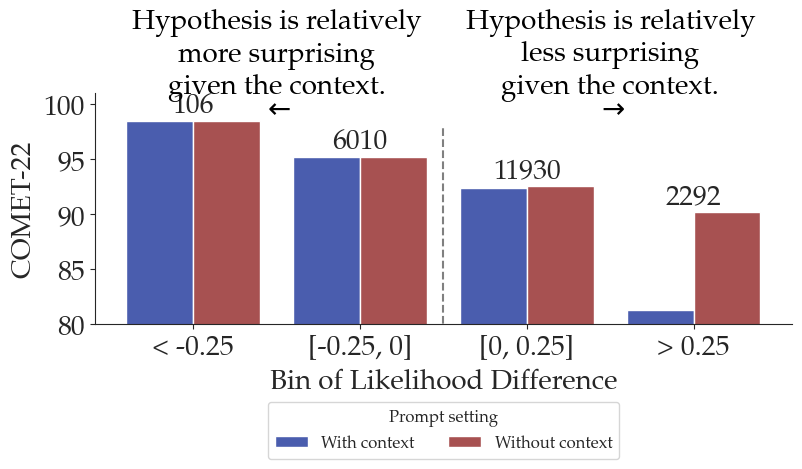

pcxmi_fc_nc_on_nc


/mnt/data/jpombal/tmp/ipykernel_250278/3742014753.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = plot_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_250278/3742014753.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = plot_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()


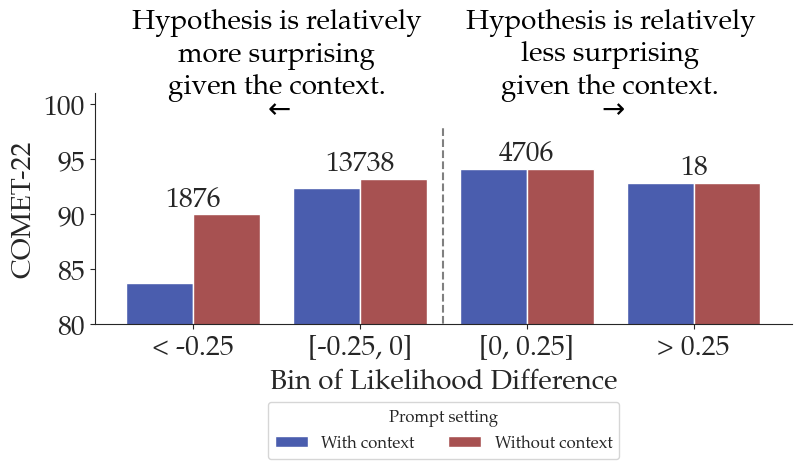

pcxmi_diff


/mnt/data/jpombal/tmp/ipykernel_250278/3742014753.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = plot_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_250278/3742014753.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = plot_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()


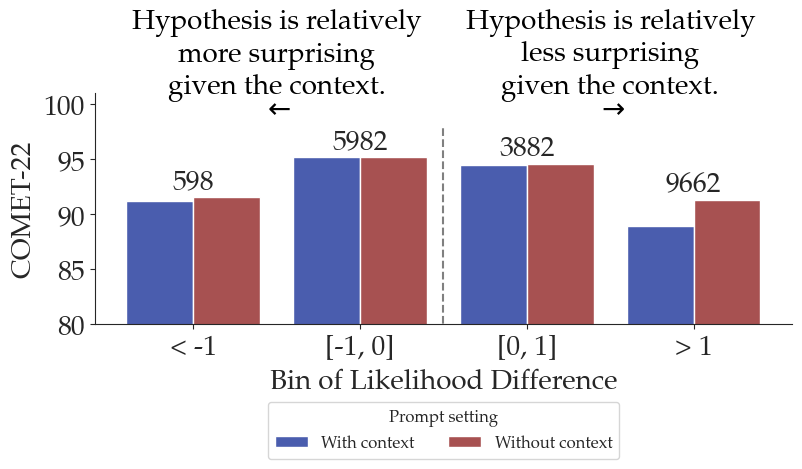

/mnt/data/jpombal/tmp/ipykernel_250278/3742014753.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = plot_df.groupby(bin_col_name).size()
/mnt/data/jpombal/tmp/ipykernel_250278/3742014753.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = plot_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()


lhood_diff


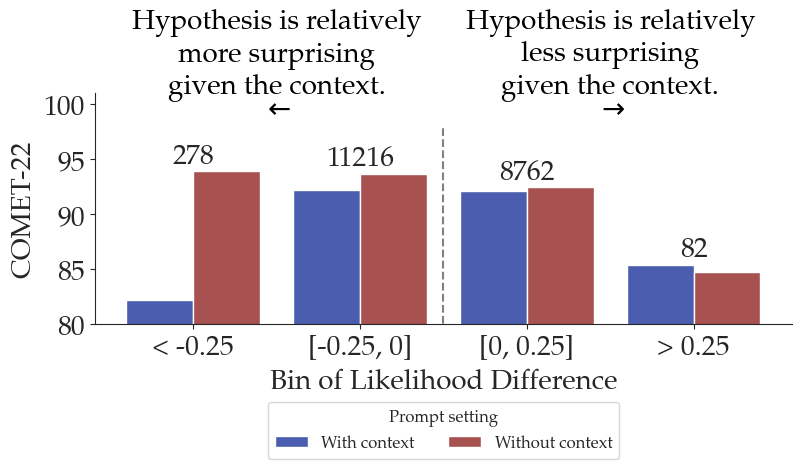

In [31]:
cmap = sns.color_palette(["#3953BF", "#b54343"])
for pcxmi_variant in pcxmi_variants:
    if pcxmi_variant == "pcxmi_diff":
        order = [
            "< -1",
            "[-1, 0]",
            "[0, 1]",
            "> 1",
        ]
        bins = [-float("inf"), -1, 0, 1, float("inf")]
    else:
        order = [
            "< -0.25",
            "[-0.25, 0]",
            "[0, 0.25]",
            "> 0.25",
        ]
        bins = [-float("inf"), -0.25, 0, 0.25, float("inf")]
    fig, ax = plt.subplots(figsize=(9, 3))
    plot_df = df.copy()
    # cut in pcxmi bins
    plot_df.loc[:, bin_col_name] = pd.cut(
        plot_df[pcxmi_variant],
        bins=bins,
        labels=order,
    )
    # Convert DataFrames into long format
    plot_df = pd.melt(
        plot_df,
        id_vars=[bin_col_name],
        value_vars=[f"{model}-wo-context-comet", f"{model}-w-context-comet"],
        var_name="model",
        value_name="comet",
    )
    plot_df["comet"] = 100 * plot_df["comet"]
    # Plot for en-xx language pairs
    sns.barplot(
        ax=ax,
        data=plot_df,
        x=bin_col_name,
        y="comet",
        hue="model",
        errorbar=None,
        hue_order=[f"{model}-w-context-comet", f"{model}-wo-context-comet"],
        palette=cmap,
        legend=True,
        order=order,
    )
    sns.despine(ax=ax, right=True, left=False)
    # ax.set_xticklabels(order)
    ax.set_xlabel("Bin of Likelihood Difference", fontsize=20)
    ax.set_ylabel("COMET-22", fontsize=20)
    ax.tick_params(axis="both", which="major", labelsize=20)
    ax.vlines(x=[1.5], ymin=72, ymax=98, color="gray", linestyle="--")
    ax.set_ylim(80, 101)
    # Calculate counts and mean heights for en-xx
    counts = plot_df.groupby(bin_col_name).size()
    means = plot_df.groupby([bin_col_name, "model"])["comet"].mean().unstack()
    # Add counts to the xx-en plot
    for i, bin_label in enumerate(order):
        if bin_label in counts.index:
            count = counts[bin_label]
            max_mean_height = means.loc[bin_label].max()
            ax.text(
                i,
                max_mean_height,
                f"{count}",
                ha="center",
                va="bottom",
                fontsize=20,
            )

    ax.annotate(
        "Hypothesis is relatively\nmore surprising\ngiven the context.",
        xy=(0.5, 101),  # position of the text
        fontsize=20,
        color="black",
        ha="center",
    )
    ax.annotate(
        r"$\leftarrow$",
        xy=(0.5, 99),  # position of the text
        fontsize=20,
        color="black",
        ha="center",
    )
    ax.annotate(
        "Hypothesis is relatively\nless surprising\ngiven the context.",
        xy=(2.5, 101),  # position of the text
        fontsize=20,
        color="black",
        ha="center",
    )
    ax.annotate(
        r"$\rightarrow$",
        xy=(2.5, 99),  # position of the text
        fontsize=20,
        color="black",
        ha="center",
    )

    # change legend title to "Prompt setting", with handles "With context" and "Without context"
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=handles,
        labels=["With context", "Without context"],
        title="Prompt setting",
        title_fontsize=12,
        bbox_to_anchor=(0.5, -0.3),
        fontsize=12,
        loc="upper center",
        ncol=2,
    )
    ax.set_yticks(range(80, 101, 5))
    # ax.annotate(
    #     "# of instances",
    #     xy=(-0.1, 91.8),  # point to which the arrow will point
    #     xytext=(-0.2, 93.5),  # position of the text
    #     arrowprops=dict(
    #         arrowstyle="->",
    #         color="black",
    #         connectionstyle="arc3,rad=0.2",  # arrow style
    #     ),
    #     fontsize=12,
    #     color="black",
    #     ha="center",
    # )
    plt.savefig(
        f"../plots/{pcxmi_variant}_bins_context_hyp_agg_{pcxmi_model}.pdf",
        bbox_inches="tight",
    )
    print(pcxmi_variant)
    plt.show()